## analysing enso characteristics and its changes in access stabilised runs

In [133]:
import warnings
warnings.filterwarnings('ignore')

In [134]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [135]:
import cmocean

In [136]:
from scipy import stats

In [137]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [138]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [7]:
### Functions needed for the analysis

In [8]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [9]:
def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 14, 'color': 'k'}
    gl.ylabel_style = {'size': 14, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160)):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
        # ax.set_aspect('auto')
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i], fontsize=16)
        if draw_winds:
            axlist[i].quiver(x[::3, ::3], y[::3, ::3], u_wnd[i].to_numpy()[::3, ::3], v_wnd[i].to_numpy()[::3, ::3], scale=wind_scale, color='k', transform=ccrs.PlateCarree())
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0))
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':16})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = cbar_orientation, shrink=0.8, aspect = 45, pad = 0.05, label = cbar_label)

In [10]:
from functions import preproc_funcs as funcs

In [11]:
from functions import xr_lowess

In [12]:
#### import data

In [13]:
ts_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/ACCESS-ESM1-5_ssp5_ts.nc', use_cftime=True).ts.load()
ts_trans = funcs.calc_anom(ts_trans_orig, ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f')).load()
pr_trans_orig = (xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/ACCESS-ESM1-5_ssp5_pr.nc', use_cftime=True).pr.load())*86400*30
pr_trans = funcs.calc_anom(pr_trans_orig, pr_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f')).load()

In [14]:
conc_ts_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_ts_original.nc', use_cftime=True).ts.load()
conc_ts_trans = funcs.calc_anom(conc_ts_trans_orig, conc_ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f')).load()
conc_pr_trans_orig = (xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_pr_original.nc', use_cftime=True).pr.load())*86400*30
conc_pr_trans = funcs.calc_anom(conc_pr_trans_orig, conc_pr_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f')).load()

In [15]:
co2_trans = (xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/ACCESS-ESM1-5_ssp5_co2.nc', use_cftime=True).co2).mean('plev').load()
co2_trans

<xarray.DataArray 'co2' (model: 3, time: 252, lat: 120, lon: 240)> Size: 87MB
array([[[[0.00028739, 0.00028739, 0.00028739, ..., 0.00028739,
          0.00028739, 0.00028739],
         [0.00028751, 0.00028751, 0.00028751, ..., 0.00028751,
          0.00028751, 0.00028751],
         [0.0002875 , 0.0002875 , 0.0002875 , ..., 0.0002875 ,
          0.0002875 , 0.0002875 ],
         ...,
         [0.00028811, 0.00028811, 0.00028811, ..., 0.00028811,
          0.00028811, 0.00028811],
         [0.00028812, 0.00028813, 0.00028813, ..., 0.00028812,
          0.00028812, 0.00028812],
         [0.00028813, 0.00028813, 0.00028813, ..., 0.00028813,
          0.00028813, 0.00028813]],

        [[0.00028768, 0.00028768, 0.00028768, ..., 0.00028768,
          0.00028768, 0.00028768],
         [0.00028768, 0.00028768, 0.00028768, ..., 0.00028768,
          0.00028768, 0.00028768],
         [0.00028768, 0.00028768, 0.00028768, ..., 0.00028768,
          0.00028768, 0.00028768],
...
         [0.00113228, 0.00113229, 0.00113229, ..., 0.00113227,
          0.00113227, 0.00113228],
         [0.00113223, 0.00113224, 0.00113224, ..., 0.00113222,
          0.00113223, 0.00113223],
         [0.0011322 , 0.0011322 , 0.0011322 , ..., 0.0011322 ,
          0.0011322 , 0.0011322 ]],

        [[0.00113379, 0.00113379, 0.00113379, ..., 0.00113379,
          0.00113379, 0.00113379],
         [0.00113681, 0.00113679, 0.00113678, ..., 0.00113683,
          0.00113683, 0.00113683],
         [0.00113684, 0.00113685, 0.00113686, ..., 0.00113682,
          0.00113683, 0.00113684],
         ...,
         [0.00114312, 0.00114313, 0.00114313, ..., 0.00114312,
          0.00114312, 0.00114312],
         [0.00114315, 0.00114315, 0.00114315, ..., 0.00114315,
          0.00114315, 0.00114315],
         [0.00114321, 0.00114321, 0.00114321, ..., 0.00114321,
          0.00114321, 0.00114321]]]], dtype=float32)
Coordinates:
  * time                (time) object 2kB 1849-06-01 00:00:00 ... 2100-06-01 ...
    latitude_longitude  float64 8B nan
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
  * model               (model) <U21 252B 'ACCESS-ESM1-5_r1i1p1f' ... 'ACCESS...

In [16]:
ts_stable_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_ts.nc', use_cftime=True).ts.load()
ts_stable = funcs.calc_anom_annual(ts_stable_orig, ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f')).load()
pr_stable_orig = (xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_pr.nc', use_cftime=True).pr.load())*86400*30
pr_stable = funcs.calc_anom_annual(pr_stable_orig, pr_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f')).load()

In [17]:
co2_stable = (xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_co2.nc', use_cftime=True).co2).load()
co2_stable

<xarray.DataArray 'co2' (model: 7, time: 1031, lat: 120, lon: 240)> Size: 831MB
array([[[[0.00044079, 0.00044079, 0.00044073, ..., 0.00044073,
          0.00044079, 0.00044079],
         [0.00043988, 0.00043987, 0.00044026, ..., 0.00043985,
          0.00043988, 0.00043988],
         [0.0004397 , 0.0004397 , 0.0004397 , ..., 0.00043971,
          0.0004397 , 0.0004397 ],
         ...,
         [0.00043844, 0.00043844, 0.00043844, ..., 0.00043844,
          0.00043844, 0.00043844],
         [0.00043842, 0.00043842, 0.00043842, ..., 0.00043842,
          0.00043842, 0.00043842],
         [0.0004384 , 0.0004384 , 0.0004384 , ..., 0.0004384 ,
          0.0004384 , 0.0004384 ]],

        [[0.00044137, 0.00044137, 0.0004414 , ..., 0.00044137,
          0.00044137, 0.00044137],
         [0.0004411 , 0.0004411 , 0.00044115, ..., 0.00044083,
          0.00044087, 0.00044096],
         [0.00044062, 0.0004407 , 0.00044072, ..., 0.0004405 ,
          0.0004405 , 0.00044052],
...
         [0.00048101, 0.00048101, 0.00048101, ..., 0.00048102,
          0.00048101, 0.00048101],
         [0.00048103, 0.00048103, 0.00048103, ..., 0.00048103,
          0.00048103, 0.00048103],
         [0.00048105, 0.00048105, 0.00048105, ..., 0.00048105,
          0.00048105, 0.00048105]],

        [[0.00048185, 0.00048185, 0.00048185, ..., 0.00048185,
          0.00048185, 0.00048185],
         [0.00048185, 0.00048185, 0.00048185, ..., 0.00048184,
          0.00048184, 0.00048184],
         [0.00048185, 0.00048185, 0.00048185, ..., 0.00048185,
          0.00048185, 0.00048185],
         ...,
         [0.00048049, 0.00048049, 0.00048049, ..., 0.00048048,
          0.00048048, 0.00048049],
         [0.00048049, 0.00048049, 0.00048049, ..., 0.00048049,
          0.00048049, 0.00048049],
         [0.00048049, 0.00048049, 0.00048049, ..., 0.00048049,
          0.00048049, 0.00048049]]]], dtype=float32)
Coordinates:
  * time                (time) object 8kB 2030-12-31 00:00:00 ... 3060-12-31 ...
  * model               (model) <U4 112B '2030' '2035' '2040' ... '2055' '2060'
    latitude_longitude  float64 8B nan
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25

### analysis

In [18]:
weights_model = np.cos(np.deg2rad(ts_trans.lat))
weights_model.name='weights'
weights_model

<xarray.DataArray 'weights' (lat: 120)> Size: 960B
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 960B -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
Attributes:
    bounds:         lat_bounds
    standard_name:  latitude
    units:          degrees_north

In [19]:
def time_series_plot(da, type = 'trans', model_identifier='B2045', **kwargs):
    da_detrend = funcs.detrend_rolling_window(da, window_size=30)
    da = da.where(da_detrend < 4*da_detrend.std('time')).isel(time = slice(1, -1))
    if type == 'trans':
        plt.plot(da.time.dt.year, da.quantile(0.5, 'model'), lw=2.0, **kwargs)
        plt.fill_between(da.time.dt.year, da.quantile(0.1, 'model'), da.quantile(0.9, 'model'), color=(kwargs['color']), alpha=0.2)
    else:
        plt.plot(da.time.dt.year, da.sel(model = model_identifier), **kwargs)

In [20]:
import seaborn as sns

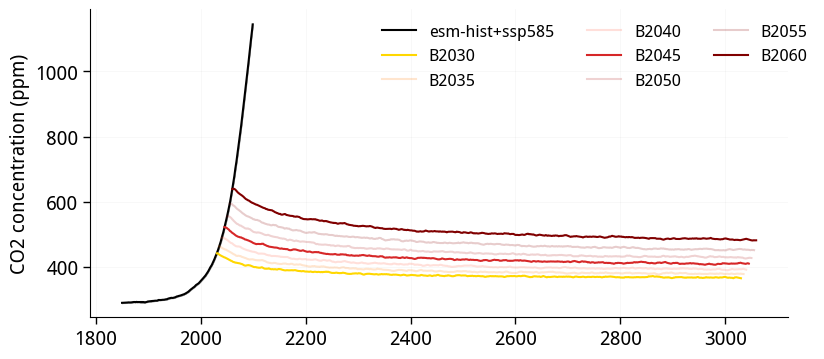

In [21]:
plt.figure(figsize=(9, 4))
xdata = (co2_trans*1e6).time.dt.year.isel(time = slice(1, -1))
plt.plot(xdata, (co2_trans*1e6).isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.5, 'model'), color='k', label='esm-hist+ssp585')
plt.fill_between(xdata, (co2_trans*1e6).isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.1, 'model'), (co2_trans*1e6).isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.9, 'model'), color='k', alpha=0.3)

xdata = (co2_stable*1e6).time.dt.year.isel(time = slice(1, -1))
plt.plot(xdata, (co2_stable*1e6).sel(model = '2030').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='gold', label = 'B2030')
plt.plot(xdata, (co2_stable*1e6).sel(model = '2035').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='tab:orange', alpha=0.2, label='B2035')
plt.plot(xdata, (co2_stable*1e6).sel(model = '2040').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='tomato', alpha=0.2, label='B2040')
plt.plot(xdata, (co2_stable*1e6).sel(model = '2045').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='tab:red', label='B2045')
plt.plot(xdata, (co2_stable*1e6).sel(model = '2050').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='firebrick', alpha=0.2, label='B2050')
plt.plot(xdata, (co2_stable*1e6).sel(model = '2055').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='darkred', alpha=0.2, label='B2055')
plt.plot(xdata, (co2_stable*1e6).sel(model = '2060').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='maroon', label='B2060')

plt.legend(frameon=False, fontsize=12, loc='upper right', ncol=3, bbox_to_anchor=(1.05, 1))
plt.ylabel('CO2 concentration (ppm)')
# plt.xlabel('Year')
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, which='minor', axis='x')
# # plt.grid(alpha=0.1, ls='--')
plot_decorator()

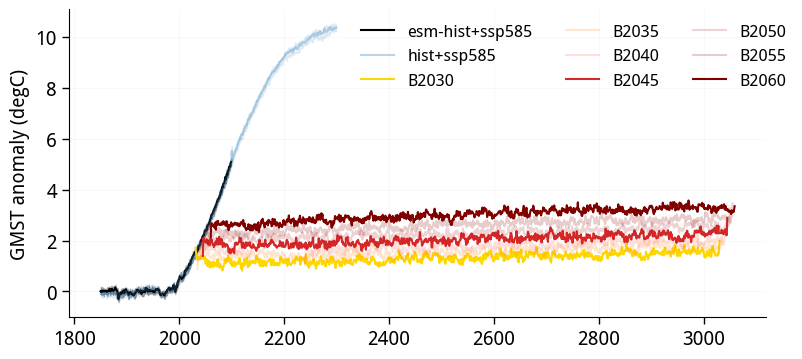

In [22]:
plt.figure(figsize=(9, 4))
xdata = ts_trans.time.dt.year.isel(time = slice(1, -1))
plt.plot(xdata, ts_trans.isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.5, 'model'), color='k', label='esm-hist+ssp585')
plt.fill_between(xdata, ts_trans.isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.1, 'model'), ts_trans.isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.9, 'model'), color='k', alpha=0.3)

xdata = conc_ts_trans.time.dt.year.isel(time = slice(1, -1))
plt.plot(xdata, conc_ts_trans.isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.5, 'model'), color='tab:blue', alpha=0.3, label='hist+ssp585')
plt.fill_between(xdata, conc_ts_trans.isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.1, 'model'), conc_ts_trans.isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')).quantile(0.9, 'model'), color='tab:blue', alpha=0.1)

xdata = ts_stable.time.dt.year.isel(time = slice(1, -1))
plt.plot(xdata, ts_stable.sel(model = '2030').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='gold', label = 'B2030')
plt.plot(xdata, ts_stable.sel(model = '2035').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='tab:orange', alpha=0.2, label='B2035')
plt.plot(xdata, ts_stable.sel(model = '2040').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='tomato', alpha=0.2, label='B2040')
plt.plot(xdata, ts_stable.sel(model = '2045').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='tab:red', label='B2045')
plt.plot(xdata, ts_stable.sel(model = '2050').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='firebrick', alpha=0.2, label='B2050')
plt.plot(xdata, ts_stable.sel(model = '2055').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='darkred', alpha=0.2, label='B2055')
plt.plot(xdata, ts_stable.sel(model = '2060').isel(time = slice(1, -1)).weighted(weights_model).mean(('lat', 'lon')), color='maroon', label='B2060')

plt.legend(frameon=False, fontsize=12, loc='upper right', ncol=3, bbox_to_anchor=(1.05, 1))
plt.ylabel('GMST anomaly (degC)')
# plt.xlabel('Year')
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, which='minor', axis='x')
# # plt.grid(alpha=0.1, ls='--')
plot_decorator()

In [21]:
ts_stable.sel(model = '2060').weighted(weights_model).mean(('lat','lon')).dropna('time')

<xarray.DataArray 'ts' (time: 1001)> Size: 8kB
array([2.13460484, 2.67256545, 2.67861213, ..., 3.23938248, 3.34697111,
       3.88065046])
Coordinates:
  * time                (time) object 8kB 2060-12-31 00:00:00 ... 3060-12-31 ...
    model               <U4 16B '2060'
    latitude_longitude  float64 8B nan

In [22]:
(co2_stable*1e6).isel(model = -1).weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('2060', '3060'))

<xarray.DataArray 'co2' (time: 1001)> Size: 8kB
array([638.77050024, 638.78641081, 639.73295537, ..., 481.15197989,
       481.63963947, 481.58019381])
Coordinates:
  * time                (time) object 8kB 2060-12-31 00:00:00 ... 3060-12-31 ...
    model               <U4 16B '2060'
    latitude_longitude  float64 8B nan

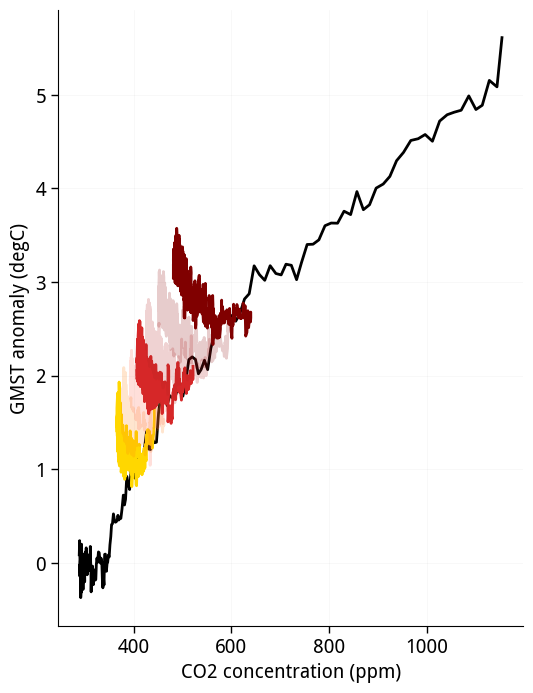

In [25]:
plt.figure(figsize=(6,8))
plt.plot((co2_trans*1e6).isel(model = 0).weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('1850', '2100')), ts_trans.sel(model = 'ACCESS-ESM1-5_r1i1p1f').weighted(weights_model).mean(('lat','lon')).sel(time = slice('1850', '2100')), color='k', lw=2.0, label='esm-hist+ssp585')
plt.plot((co2_stable*1e6).sel(model = '2030').weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('2030', '3030')).isel(time = slice(1, -1)), ts_stable.sel(model = '2030').weighted(weights_model).mean(('lat','lon')).dropna('time').isel(time = slice(1, -1)), color='gold', lw=2.0, label='B2030')
plt.plot((co2_stable*1e6).sel(model = '2035').weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('2035', '3035')).isel(time = slice(1, -1)), ts_stable.sel(model = '2035').weighted(weights_model).mean(('lat','lon')).dropna('time').isel(time = slice(1, -1)), color='tab:orange', lw=2.0, label='B2035', alpha=0.2)
plt.plot((co2_stable*1e6).sel(model = '2040').weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('2040', '3040')).isel(time = slice(0, 902)).isel(time = slice(1, -1)), ts_stable.sel(model = '2040').weighted(weights_model).mean(('lat','lon')).dropna('time').isel(time = slice(1, -1)), color='tomato', lw=2.0, label='B2040', alpha=0.2)
plt.plot((co2_stable*1e6).sel(model = '2045').weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('2045', '3045')).isel(time = slice(1, -1)), ts_stable.sel(model = '2045').weighted(weights_model).mean(('lat','lon')).dropna('time').isel(time = slice(1, -1)), color='tab:red', lw=2.0, label='B2045')
plt.plot((co2_stable*1e6).sel(model = '2050').weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('2050', '3050')).isel(time = slice(1, -1)), ts_stable.sel(model = '2050').weighted(weights_model).mean(('lat','lon')).dropna('time').isel(time = slice(1, -1)), color='firebrick', lw=2.0, label='B2050', alpha=0.2)
plt.plot((co2_stable*1e6).sel(model = '2055').weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('2055', '3055')).isel(time = slice(1, -1)), ts_stable.sel(model = '2055').weighted(weights_model).mean(('lat','lon')).dropna('time').isel(time = slice(1, -1)), color='darkred', lw=2.0, label='B2055', alpha=0.2)
plt.plot((co2_stable*1e6).sel(model = '2060').weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('2060', '3060')).isel(time = slice(1, -1)), ts_stable.sel(model = '2060').weighted(weights_model).mean(('lat','lon')).dropna('time').isel(time = slice(1, -1)), color='maroon', lw=2.0, label='B2060')

# plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=3, bbox_to_anchor=(1.05, 1))
plt.ylabel('GMST anomaly (degC)')
plt.xlabel('CO2 concentration (ppm)')
# plt.xlabel('Year')
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, which='minor', axis='x')
# # plt.grid(alpha=0.1, ls='--')
plot_decorator()

In [21]:
def rolling_window_smoothing(da, window_size=30):
    pad_size=window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    smoothed_data = padded_data.rolling(time=window_size, center=True).mean('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return smoothed_data

In [22]:
def rolling_window_std(da, window_size=30):
    pad_size=window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    std_data = padded_data.rolling(time=window_size, center=True).std('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return std_data

In [23]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [24]:
ts_stable

<xarray.DataArray 'ts' (model: 7, time: 1031, lat: 120, lon: 240)> Size: 831MB
array([[[[ 4.974472  ,  4.979782  ,  4.982483  , ...,  4.964569  ,
           4.970001  ,  4.973282  ],
         [ 4.6117554 ,  4.62825   ,  4.640167  , ...,  4.562393  ,
           4.5790863 ,  4.594513  ],
         [ 4.87117   ,  4.902298  ,  4.9393005 , ...,  4.75856   ,
           4.7960205 ,  4.831909  ],
         ...,
         [-2.4626312 , -2.4781952 , -2.482727  , ..., -2.375824  ,
          -2.406128  , -2.4365234 ],
         [-2.716568  , -2.7285156 , -2.7358093 , ..., -2.668167  ,
          -2.6862946 , -2.7051086 ],
         [-2.8918762 , -2.8995209 , -2.9029999 , ..., -2.882782  ,
          -2.884842  , -2.8877869 ]],

        [[ 1.696228  ,  1.6959839 ,  1.6946259 , ...,  1.6999054 ,
           1.6974945 ,  1.6960907 ],
         [ 1.6032257 ,  1.6126251 ,  1.6244507 , ...,  1.5655823 ,
           1.5769958 ,  1.5905762 ],
         [ 1.6693726 ,  1.6999207 ,  1.7281647 , ...,  1.5888367 ,
           1.6192932 ,  1.644867  ],
...
         [ 7.3176117 ,  7.3373566 ,  7.3743896 , ...,  7.364258  ,
           7.3371887 ,  7.3194733 ],
         [ 7.5643463 ,  7.5613403 ,  7.5624847 , ...,  7.5747223 ,
           7.5708923 ,  7.567581  ],
         [ 8.000946  ,  8.001297  ,  8.001556  , ...,  7.9997253 ,
           7.998596  ,  8.000275  ]],

        [[ 1.7797852 ,  1.7875824 ,  1.799057  , ...,  1.7389221 ,
           1.7532196 ,  1.7672424 ],
         [ 2.175583  ,  2.2043152 ,  2.2388458 , ...,  2.0646973 ,
           2.101059  ,  2.1401215 ],
         [ 2.5598145 ,  2.619812  ,  2.682602  , ...,  2.3806458 ,
           2.4421082 ,  2.5034637 ],
         ...,
         [13.649704  , 13.661423  , 13.673981  , ..., 13.629181  ,
          13.631378  , 13.638687  ],
         [14.011063  , 14.011871  , 14.021164  , ..., 14.010696  ,
          14.008148  , 14.009384  ],
         [14.442688  , 14.444931  , 14.446899  , ..., 14.434967  ,
          14.43634   , 14.438385  ]]]], dtype=float32)
Coordinates:
  * time                (time) object 8kB 2030-12-31 00:00:00 ... 3060-12-31 ...
  * model               (model) <U4 112B '2030' '2035' '2040' ... '2055' '2060'
    latitude_longitude  float64 8B nan
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25

In [ ]:
additional_sampling_stabilisation_nomeans(ts_stable.sel(model = '2060').sel(time = slice('2060', '3060')))

Done


<xarray.DataArray 'ts' (model: 30, time: 900, lat: 120, lon: 240)>
array([[[[ 1.905365 ,  1.9070892,  1.9092255, ...,  1.8973999,
           1.8989105,  1.9007416],
         [ 1.4336548,  1.4411774,  1.4536133, ...,  1.408844 ,
           1.414917 ,  1.4227753],
         [ 1.2581177,  1.2846832,  1.3100739, ...,  1.2105865,
           1.224411 ,  1.2402039],
         ...,
         [10.593369 , 10.595566 , 10.609589 , ..., 10.576447 ,
          10.577728 , 10.583847 ],
         [10.357285 , 10.350403 , 10.347092 , ..., 10.369797 ,
          10.368317 , 10.364914 ],
         [10.238922 , 10.240982 , 10.240265 , ..., 10.244232 ,
          10.242859 , 10.241455 ]],

        [[ 3.103592 ,  3.098587 ,  3.0980072, ...,  3.1101074,
           3.1069794,  3.1046753],
         [ 2.9474945,  2.9491577,  2.951233 , ...,  2.950882 ,
           2.9490814,  2.9478607],
         [ 2.7958832,  2.803238 ,  2.812088 , ...,  2.763855 ,
           2.7745514,  2.7860718],
...
         [ 6.8196564,  6.8005524,  6.7838135, ...,  6.8780518,
           6.858246 ,  6.8374176],
         [ 6.5078583,  6.502838 ,  6.500534 , ...,  6.5305634,
           6.523102 ,  6.517807 ],
         [ 6.4823303,  6.4792633,  6.4767456, ...,  6.488434 ,
           6.4877014,  6.485626 ]],

        [[ 6.6495667,  6.6581726,  6.662079 , ...,  6.6415405,
           6.6456757,  6.6486664],
         [ 6.896057 ,  6.901703 ,  6.903137 , ...,  6.883072 ,
           6.8848724,  6.8895264],
         [ 7.352524 ,  7.3680115,  7.3833466, ...,  7.2807617,
           7.306732 ,  7.329788 ],
         ...,
         [ 7.3176117,  7.3373566,  7.3743896, ...,  7.364258 ,
           7.3371887,  7.3194733],
         [ 7.5643463,  7.5613403,  7.5624847, ...,  7.5747223,
           7.5708923,  7.567581 ],
         [ 8.000946 ,  8.001297 ,  8.001556 , ...,  7.9997253,
           7.998596 ,  8.000275 ]]]], dtype=float32)
Coordinates:
  * time                (time) object 2160-12-31 00:00:00 ... 3059-12-31 00:0...
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
    latitude_longitude  float64 nan
  * model               (model) float64 0.0 1.0 2.0 3.0 ... 26.0 27.0 28.0 29.0

In [27]:
import glob

In [25]:
ts_pic_loaded = xr.open_dataset('/g/data/if69/as8561/data/piControl_data/ts_pic.nc').sortby('model').isel(model=1).ts
pr_pic_loaded = (xr.open_dataset('/g/data/if69/as8561/data/piControl_data/pr_pic.nc').sortby('model').isel(model=1).pr*86400*30)

In [26]:
# nino34_pic_index = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon'))
nino3_pic_index = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
# nino4_pic_index = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(160, -150+360)).weighted(weights_model).mean(('lat', 'lon'))

In [27]:
nino3_pic = ts_pic_loaded.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
nino3_north_pic = ts_pic_loaded.sel(lat = slice(5, 10), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))

In [28]:
nino3_pr_pic = pr_pic_loaded.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))

Text(0, 0.5, 'Nino3 index (K)')

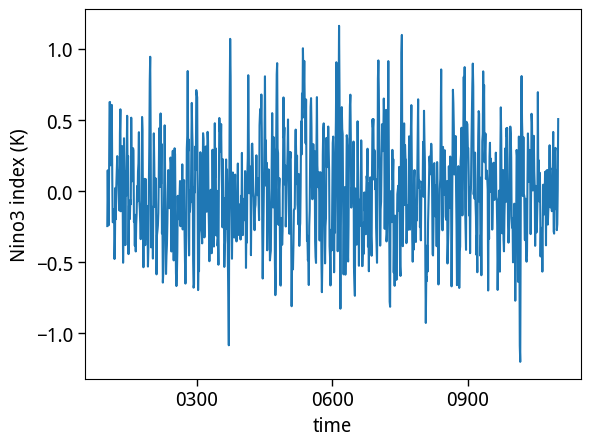

In [29]:
nino3_pic_index.rolling(time = 3, center=True).mean('time').plot()
plt.ylabel('Nino3 index (K)')

Text(0, 0.5, 'Nino3 temperature (K)')

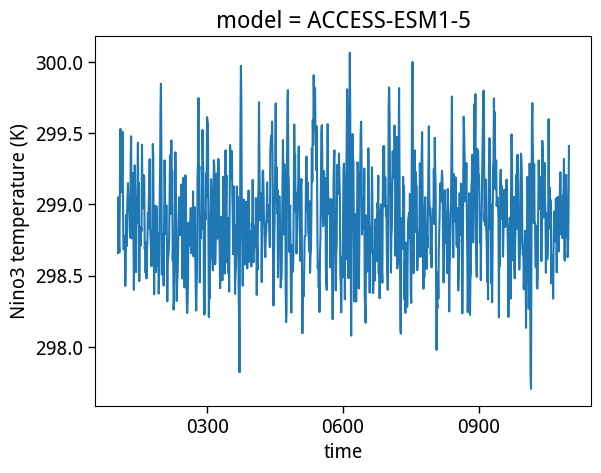

In [30]:
nino3_pic.rolling(time = 3, center=True).mean('time').plot()
plt.ylabel('Nino3 temperature (K)')

In [31]:
sst_grad_pic = (ts_pic_loaded.sel(lat=slice(-5,5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - ts_pic_loaded.sel(lat=slice(-5,5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon')))
sst_grad_pic

<xarray.DataArray 'ts' (time: 2001)> Size: 16kB
array([3.14270639, 2.18628441, 2.62412474, ...,        nan,        nan,
              nan])
Coordinates:
  * time     (time) object 16kB 0100-12-31 00:00:00 ... 2100-12-31 00:00:00
    model    <U16 64B 'ACCESS-ESM1-5'

In [32]:
# nino34_trans = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
# print('done')
# conc_nino34_trans = funcs.detrend_rolling_window(conc_ts_trans.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
# print('done')
# nino34_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
# print('done')

nino3_trans_index = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
conc_nino3_trans_index = funcs.detrend_rolling_window(conc_ts_trans.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
nino3_stable_index = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)

In [33]:
nino3_trans = ts_trans_orig.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
nino3_north_trans = ts_trans_orig.sel(lat = slice(5, 10), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))

conc_nino3_trans = conc_ts_trans_orig.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
conc_nino3_north_trans = conc_ts_trans_orig.sel(lat = slice(5, 10), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))

nino3_stable = ts_stable_orig.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
nino3_north_stable = ts_stable_orig.sel(lat = slice(5, 10), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))

In [34]:
nino3_pr_trans = pr_trans_orig.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
conc_nino3_pr_trans = conc_pr_trans_orig.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
nino3_pr_stable = pr_stable_orig.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))

In [35]:
conc_pr_trans

<xarray.DataArray 'pr' (model: 40, time: 452, lat: 120, lon: 240)> Size: 4GB
array([[[[ 6.51838977e-01,  6.18083086e-01,  6.33706965e-01, ...,
           6.67690907e-01,  6.58036998e-01,  6.56468408e-01],
         [ 6.67357742e-01,  6.91274781e-01,  7.19457688e-01, ...,
           5.75690500e-01,  6.14687655e-01,  6.45160738e-01],
         [ 2.29879440e-01,  3.26877433e-01,  4.16219737e-01, ...,
          -1.14256594e-01,  1.04208465e-02,  1.27419384e-01],
         ...,
         [-1.98796305e+00, -2.06670725e+00, -2.22343134e+00, ...,
          -1.67538368e+00, -1.75287438e+00, -1.85172694e+00],
         [-4.07024076e+00, -4.04316990e+00, -4.01751595e+00, ...,
          -4.19878270e+00, -4.14628622e+00, -4.08186789e+00],
         [-3.73256604e+00, -3.77174863e+00, -3.70918909e+00, ...,
          -3.74520568e+00, -3.71323372e+00, -3.70570738e+00]],

        [[-1.16122522e+00, -1.15674745e+00, -1.15717165e+00, ...,
          -1.17734685e+00, -1.17248323e+00, -1.16737800e+00],
         [-1.31546711e+00, -1.32521447e+00, -1.32452870e+00, ...,
          -1.32323117e+00, -1.32058292e+00, -1.31916492e+00],
         [-1.22747335e+00, -1.22612905e+00, -1.22532135e+00, ...,
          -1.23818317e+00, -1.23446003e+00, -1.23515520e+00],
...
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]]]])
Coordinates:
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
  * lat      (lat) float64 960B -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
  * time     (time) object 4kB 1849-06-01 00:00:00 ... 2300-06-01 00:00:00
  * model    (model) <U22 4kB 'ACCESS-ESM1-5_r6i1p1f' ... 'ACCESS-ESM1-5_r27i...
    month    (time) int64 4kB 6 6 6 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6 6 6

In [36]:
nino3_mag_trans = rolling_window_std(nino3_trans_index, window_size=30).isel(time = slice(15, -15))
conc_nino3_mag_trans = rolling_window_std(conc_nino3_trans_index, window_size=30).isel(time = slice(15, -15))
nino3_mag_stable = rolling_window_std(nino3_stable_index, window_size=30).isel(time = slice(15, -15))

In [37]:
nino3_mag_pic = rolling_window_std(funcs.detrend_separate_check(nino3_pic_index, period=15, dim='time'), window_size=30).isel(time = slice(15, -15))

In [38]:
# nino3_mag_trans = rolling_window_std(nino3_trans, window_size=30).isel(time = slice(15, -15))
# nino3_mag_stable = rolling_window_std(nino3_stable, window_size=30).isel(time = slice(15, -15))

In [39]:
# nino4_mag_trans = rolling_window_std(nino4_trans, window_size=30).isel(time = slice(15, -15))
# nino4_mag_stable = rolling_window_std(nino4_stable, window_size=30).isel(time = slice(15, -15))

Text(0, 0.5, 'ENSO magnitude (degC)')

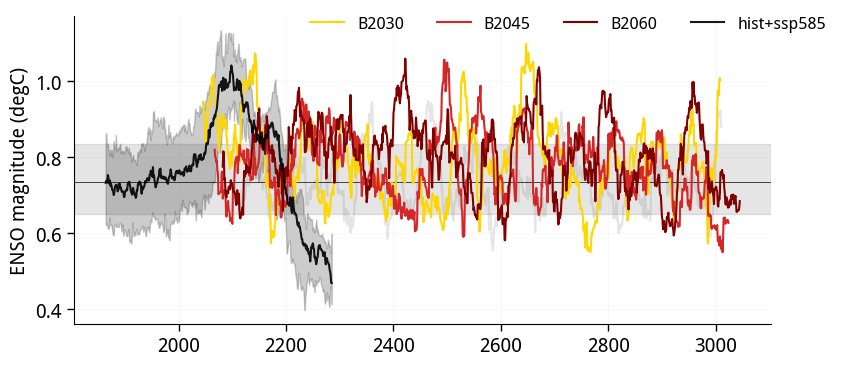

In [42]:
plt.figure(figsize=(9,4))

xdata = nino3_mag_pic.time.dt.year + 2000
plt.plot(xdata, nino3_mag_pic, color='tab:gray', alpha=0.2)
plt.axhspan(nino3_mag_pic.quantile(0.1, 'time'), nino3_mag_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.2)
plt.axhline(nino3_mag_pic.quantile(0.5, 'time'), color='k', lw=0.5)

plt.plot(nino3_mag_stable.time.dt.year, nino3_mag_stable.sel(model = '2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(nino3_mag_stable.sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(nino3_mag_stable.time.dt.year, nino3_mag_stable.sel(model = '2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(nino3_mag_stable.sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(nino3_mag_stable.time.dt.year, nino3_mag_stable.sel(model = '2060'), color='maroon', lw=1.5, label='B2060')
# plt.axhline(nino3_mag_stable.sel(model='B2060').quantile(0.5, dim='time'), color='maroon')

# plt.plot(nino3_mag_trans.time.dt.year, nino3_mag_trans.quantile(0.5, 'model'), color='k', lw=1.5, label='esm-hist+ssp585')
# plt.plot(nino3_mag_trans.time.dt.year, nino3_mag_trans.sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
# plt.fill_between(nino3_mag_trans.time.dt.year, nino3_mag_trans.quantile(0.1, 'model'), nino3_mag_trans.quantile(0.9, 'model'), color='k', alpha=0.3)

plt.plot(conc_nino3_mag_trans.time.dt.year, conc_nino3_mag_trans.quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585', alpha=0.9)
# plt.plot(nino3_mag_trans.time.dt.year, nino3_mag_trans.sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(conc_nino3_mag_trans.time.dt.year, conc_nino3_mag_trans.quantile(0.1, 'model'), conc_nino3_mag_trans.quantile(0.9, 'model'), color='k', alpha=0.2)

## plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# # plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
# plt.ylim(0, 1.2)
# sns.despine(left=True, trim=True)
# plt.yticks([])
# # plt.minorticks_on()
# # plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=12, loc='upper right', ncol=5, bbox_to_anchor=(1.1, 1.05))
plot_decorator()
plt.ylabel('ENSO magnitude (degC)')
# plt.xlabel('Year')


In [127]:
def plot_dist_inset(ax, val, yval, color, dim=("time")):
    # Error bars (0.1, 0.5, 0.9 quantiles)
    q10 = val.quantile(0.1, dim=dim)
    q50 = val.quantile(0.5, dim=dim)
    q90 = val.quantile(0.9, dim=dim)
    
    ax.errorbar(
        x=q50, y=yval,
        xerr=[[q50 - q10], [q90 - q50]],
        fmt="o", color=color, mfc="white", mec=color,
        capsize=4, lw=2.0, ms=6, mew=1.2, zorder=5
    )
    

Text(0.5, 0, 'ENSO Magnitude (degC)')

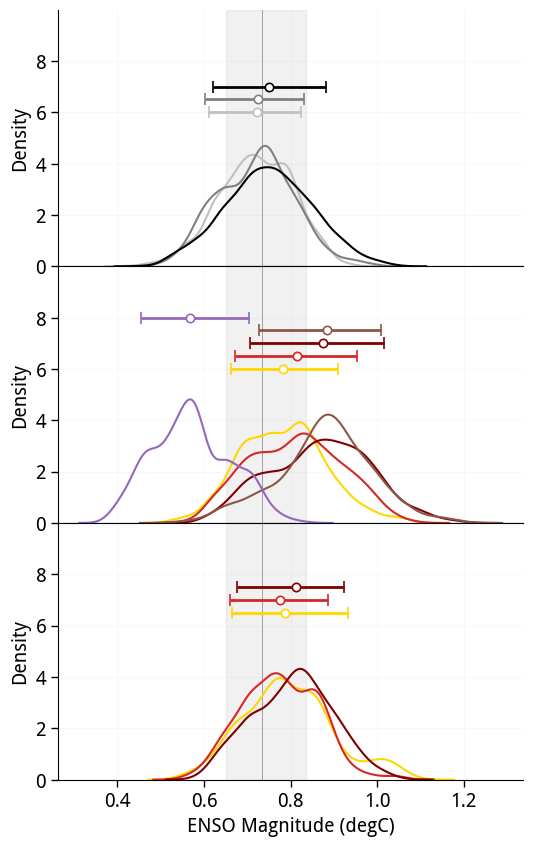

In [128]:
fig, axarr = plt.subplots(nrows=3, ncols=1, figsize=(6,10), constrained_layout=False, sharex=True, sharey=True)
axlist = axarr.flatten()


###
axlist[0].axvline(nino3_mag_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[0].axvspan(nino3_mag_pic.quantile(0.1, 'time'), nino3_mag_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(np.ravel(conc_nino3_mag_trans.sel(time = slice('1850', '1900'))), color='silver', ax=axlist[0], label='historical \n1850-1900')
sns.kdeplot(np.ravel(conc_nino3_mag_trans.sel(time = slice('1900', '1950'))), color='gray', ax=axlist[0], label='1900-1950')
sns.kdeplot(np.ravel(conc_nino3_mag_trans.sel(time = slice('1950', '2000'))), color='k', ax=axlist[0], label='1950-2000')
# axlist[0].axvline(np.mean(np.ravel(conc_nino3_mag_trans.sel(time = slice('1850', '1900')))), color='k', lw=1.0)
plot_dist_inset(axlist[0], conc_nino3_mag_trans.sel(time = slice('1850', '1900')), 6, color='silver', dim=(("time", "model")))
plot_dist_inset(axlist[0], conc_nino3_mag_trans.sel(time = slice('1900', '1950')), 6.5, color='gray', dim=(("time", "model")))
plot_dist_inset(axlist[0], conc_nino3_mag_trans.sel(time = slice('1950', '2000')), 7, color='k', dim=(("time", "model")))

###
axlist[1].axvline(nino3_mag_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[1].axvspan(nino3_mag_pic.quantile(0.1, 'time'), nino3_mag_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)

sns.kdeplot(np.ravel(conc_nino3_mag_trans.sel(time = slice('2015', '2045'))), color='gold', ax=axlist[1], label='ssp585 \n2015-2045')
plot_dist_inset(axlist[1], conc_nino3_mag_trans.sel(time = slice('2015', '2045')), 6, color='gold', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_nino3_mag_trans.sel(time = slice('2015', '2045')))), color='gold', lw=1.0)

sns.kdeplot(np.ravel(conc_nino3_mag_trans.sel(time = slice('2030', '2060'))), color='tab:red', ax=axlist[1], label='2030-2060')
plot_dist_inset(axlist[1], conc_nino3_mag_trans.sel(time = slice('2030', '2060')), 6.5, color='tab:red', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_nino3_mag_trans.sel(time = slice('2030', '2060')))), color='tab:red', lw=1.0)

sns.kdeplot(np.ravel(conc_nino3_mag_trans.sel(time = slice('2045', '2075'))), color='maroon', ax=axlist[1], label='2045-2075')
plot_dist_inset(axlist[1], conc_nino3_mag_trans.sel(time = slice('2045', '2075')), 7.0, color='maroon', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_nino3_mag_trans.sel(time = slice('2045', '2075')))), color='maroon', lw=1.0)

sns.kdeplot(np.ravel(conc_nino3_mag_trans.sel(time = slice('2100', '2200'))), color='tab:brown', ax=axlist[1], label='2100-2200')
plot_dist_inset(axlist[1], conc_nino3_mag_trans.sel(time = slice('2100', '2200')), 7.5, color='tab:brown', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(conc_nino3_mag_trans.sel(time = slice('2100', '2200')))), color='tab:brown', lw=1.0)

sns.kdeplot(np.ravel(conc_nino3_mag_trans.sel(time = slice('2200', '2300'))), color='tab:purple', ax=axlist[1], label='2200-2300')
plot_dist_inset(axlist[1], conc_nino3_mag_trans.sel(time = slice('2200', '2300')), 8.0, color='tab:purple', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(conc_nino3_mag_trans.sel(time = slice('2200', '2300')))), color='tab:purple', lw=1.0)

###
axlist[2].axvline(nino3_mag_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[2].axvspan(nino3_mag_pic.quantile(0.1, 'time'), nino3_mag_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(nino3_mag_stable.sel(model='2030'), color='gold', ax=axlist[2], label='NZ2030')
plot_dist_inset(axlist[2], nino3_mag_stable.sel(model = '2030'), 6.5, color='gold', dim=(("time")))
# axlist[2].axvline(nino3_mag_stable.sel(model = 'B2030').mean('time'), color='gold', lw=1.0)

sns.kdeplot(nino3_mag_stable.sel(model='2045'), color='tab:red', ax=axlist[2], label='NZ2045')
plot_dist_inset(axlist[2], nino3_mag_stable.sel(model = '2045'), 7.0, color='tab:red', dim=(("time")))
# axlist[2].axvline(nino3_mag_stable.sel(model = 'B2045').mean('time'), color='tab:red', lw=1.0)

sns.kdeplot(nino3_mag_stable.sel(model='2060'), color='maroon', ax=axlist[2], label='NZ2060')
plot_dist_inset(axlist[2], nino3_mag_stable.sel(model = '2060'), 7.5, color='maroon', dim=(("time")))
# axlist[2].axvline(nino3_mag_stable.sel(model = 'B2060').mean('time'), color='maroon', lw=1.0)

for ax in np.ravel(axlist):
#     # axlist[j].
#     pass
    # ax.legend(frameon=False, fontsize=11, loc='upper right', bbox_to_anchor=(1.05, 1))
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    # ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# sns.despine(trim=True, bottom=False)
# sns.despine()
# plt.xticks([])
plt.ylim(0, 10)
# plt.ylim(0, 0.9)
plt.gca().set_yticks(np.arange(0, 10, 2))
plt.subplots_adjust(wspace=0.0, hspace=0.0)
axlist[0].spines['top'].set_visible(False)
# plt.minorticks_on()
plt.xlabel('ENSO Magnitude (degC)')

In [129]:
sst_grad_trans = ts_trans_orig.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - ts_trans_orig.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon'))
rolling_sst_grad_trans = (rolling_window_smoothing(sst_grad_trans, window_size=30)).isel(time = slice(15, -15))

conc_sst_grad_trans = conc_ts_trans_orig.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - conc_ts_trans_orig.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon'))
conc_rolling_sst_grad_trans = (rolling_window_smoothing(conc_sst_grad_trans, window_size=30)).isel(time = slice(15, -15))

sst_grad_stable = ts_stable_orig.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - ts_stable_orig.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon'))
rolling_sst_grad_stable = (rolling_window_smoothing(sst_grad_stable, window_size=30)).isel(time = slice(15, -15))

In [130]:
rolling_sst_grad_pic = rolling_window_smoothing(sst_grad_pic, window_size=30).isel(time = slice(15, -15))

In [141]:

mtg_pic = nino3_north_pic - nino3_pic
rolling_mtg_pic = (rolling_window_smoothing(mtg_pic, window_size=30)).isel(time = slice(15, -15))


conc_mtg_trans = conc_nino3_north_trans - conc_nino3_trans
conc_rolling_mtg_trans = (rolling_window_smoothing(conc_mtg_trans, window_size=30)).isel(time = slice(15, -15))

mtg_trans = nino3_north_trans - nino3_trans
rolling_mtg_trans = (rolling_window_smoothing(mtg_trans, window_size=30)).isel(time = slice(15, -15))

mtg_stable = nino3_north_stable - nino3_stable
rolling_mtg_stable = (rolling_window_smoothing(mtg_stable, window_size=30)).isel(time = slice(15, -15))


Text(0, 0.5, 'ZTG (degC)')

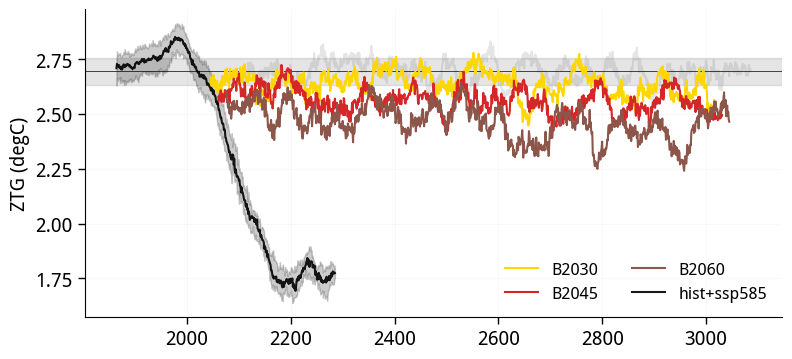

In [142]:
plt.figure(figsize=(9,4))

xdata = rolling_sst_grad_pic.time.dt.year + 2000
plt.plot(xdata, rolling_sst_grad_pic, color='tab:gray', alpha=0.2)
plt.axhspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.2)
plt.axhline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='k', lw=0.5)

plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = '2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(rolling_sst_grad_stable.sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = '2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(rolling_sst_grad_stable.sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = '2060'), color='tab:brown', lw=1.5, label='B2060')
# plt.axhline(rolling_sst_grad_stable.sel(model='B2060').quantile(0.5, dim='time'), color='tab:brown')

# plt.plot(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.quantile(0.5, 'model'), color='k', lw=1.5, label='esm-hist+ssp585')
# plt.plot(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp585 r10')
# plt.fill_between(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.quantile(0.1, 'model'), rolling_sst_grad_trans.quantile(0.9, 'model'), color='k', alpha=0.3)

plt.plot(conc_rolling_sst_grad_trans.time.dt.year, conc_rolling_sst_grad_trans.quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585', alpha=0.9)
# plt.plot(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp585 r10')
plt.fill_between(conc_rolling_sst_grad_trans.time.dt.year, conc_rolling_sst_grad_trans.quantile(0.1, 'model'), conc_rolling_sst_grad_trans.quantile(0.9, 'model'), color='k', alpha=0.2)

# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
# plt.ylim(-1.4, 0.5)
# sns.despine(left=True, trim=True)
# plt.yticks([])
# # plt.minorticks_on()
# # plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=2)
# plt.axhline(0.0, color='k', lw=0.5)
plot_decorator()
plt.ylabel('ZTG (degC)')
# plt.xlabel('Year')


Text(0.5, 0, 'ZTG (degC)')

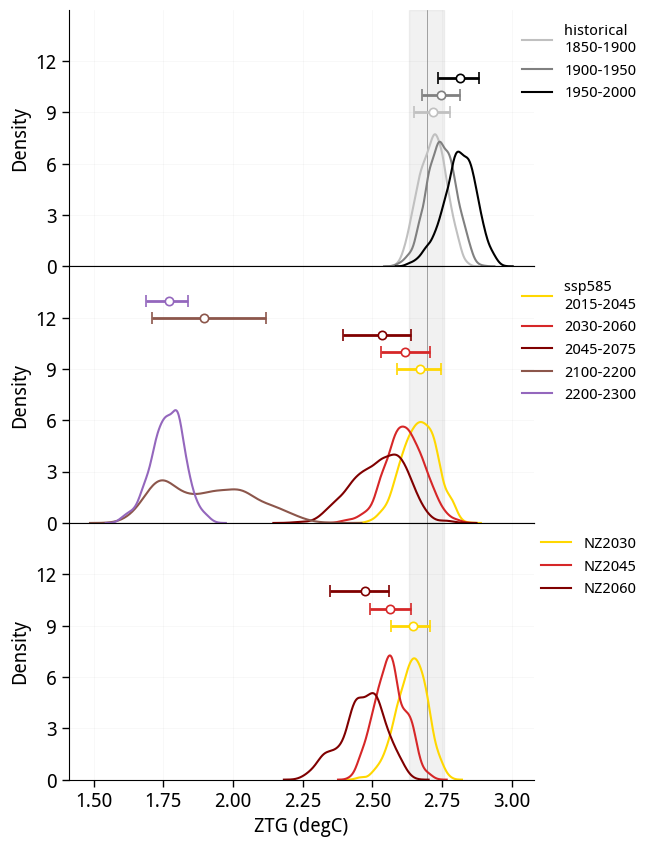

In [132]:
fig, axarr = plt.subplots(nrows=3, ncols=1, figsize=(6,10), constrained_layout=False, sharex=True, sharey=True)
axlist = axarr.flatten()


###
axlist[0].axvline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[0].axvspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('1850', '1900'))), color='silver', ax=axlist[0], label='historical \n1850-1900')
sns.kdeplot(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('1900', '1950'))), color='gray', ax=axlist[0], label='1900-1950')
sns.kdeplot(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('1950', '2000'))), color='k', ax=axlist[0], label='1950-2000')
# axlist[0].axvline(np.mean(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('1850', '1900')))), color='k', lw=1.0)
plot_dist_inset(axlist[0], conc_rolling_sst_grad_trans.sel(time = slice('1850', '1900')), 9, color='silver', dim=(("time", "model")))
plot_dist_inset(axlist[0], conc_rolling_sst_grad_trans.sel(time = slice('1900', '1950')), 10, color='gray', dim=(("time", "model")))
plot_dist_inset(axlist[0], conc_rolling_sst_grad_trans.sel(time = slice('1950', '2000')), 11, color='k', dim=(("time", "model")))

###
axlist[1].axvline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[1].axvspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)

sns.kdeplot(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2015', '2045'))), color='gold', ax=axlist[1], label='ssp585 \n2015-2045')
plot_dist_inset(axlist[1], conc_rolling_sst_grad_trans.sel(time = slice('2015', '2045')), 9, color='gold', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2015', '2045')))), color='gold', lw=1.0)

sns.kdeplot(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2030', '2060'))), color='tab:red', ax=axlist[1], label='2030-2060')
plot_dist_inset(axlist[1], conc_rolling_sst_grad_trans.sel(time = slice('2030', '2060')), 10, color='tab:red', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2030', '2060')))), color='tab:red', lw=1.0)

sns.kdeplot(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2045', '2075'))), color='maroon', ax=axlist[1], label='2045-2075')
plot_dist_inset(axlist[1], conc_rolling_sst_grad_trans.sel(time = slice('2045', '2075')), 11.0, color='maroon', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2045', '2075')))), color='maroon', lw=1.0)

sns.kdeplot(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2100', '2200'))), color='tab:brown', ax=axlist[1], label='2100-2200')
plot_dist_inset(axlist[1], conc_rolling_sst_grad_trans.sel(time = slice('2100', '2200')), 12, color='tab:brown', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2100', '2200')))), color='tab:brown', lw=1.0)

sns.kdeplot(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2200', '2300'))), color='tab:purple', ax=axlist[1], label='2200-2300')
plot_dist_inset(axlist[1], conc_rolling_sst_grad_trans.sel(time = slice('2200', '2300')), 13, color='tab:purple', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(conc_rolling_sst_grad_trans.sel(time = slice('2200', '2300')))), color='tab:purple', lw=1.0)

###
axlist[2].axvline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[2].axvspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(rolling_sst_grad_stable.sel(model='2030'), color='gold', ax=axlist[2], label='NZ2030')
plot_dist_inset(axlist[2], rolling_sst_grad_stable.sel(model = '2030'), 9.0, color='gold', dim=(("time")))
# axlist[2].axvline(rolling_sst_grad_stable.sel(model = 'B2030').mean('time'), color='gold', lw=1.0)

sns.kdeplot(rolling_sst_grad_stable.sel(model='2045'), color='tab:red', ax=axlist[2], label='NZ2045')
plot_dist_inset(axlist[2], rolling_sst_grad_stable.sel(model = '2045'), 10, color='tab:red', dim=(("time")))
# axlist[2].axvline(rolling_sst_grad_stable.sel(model = 'B2045').mean('time'), color='tab:red', lw=1.0)

sns.kdeplot(rolling_sst_grad_stable.sel(model='2060'), color='maroon', ax=axlist[2], label='NZ2060')
plot_dist_inset(axlist[2], rolling_sst_grad_stable.sel(model = '2060'), 11, color='maroon', dim=(("time")))
# axlist[2].axvline(rolling_sst_grad_stable.sel(model = 'B2060').mean('time'), color='maroon', lw=1.0)

for ax in np.ravel(axlist):
#     # axlist[j].
#     pass
    ax.legend(frameon=False, fontsize=11, loc='upper right', bbox_to_anchor=(1.25, 1))
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    # ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# sns.despine(trim=True, bottom=False)
# sns.despine()
# plt.xticks([])
plt.ylim(0, 15)
# plt.xlim(-1.6, 0.2)
plt.gca().set_yticks(np.arange(0, 15, 3))
plt.subplots_adjust(wspace=0.0, hspace=0.0)
axlist[0].spines['top'].set_visible(False)
# plt.minorticks_on()
plt.xlabel('ZTG (degC)')

Text(0, 0.5, 'MTG (degC)')

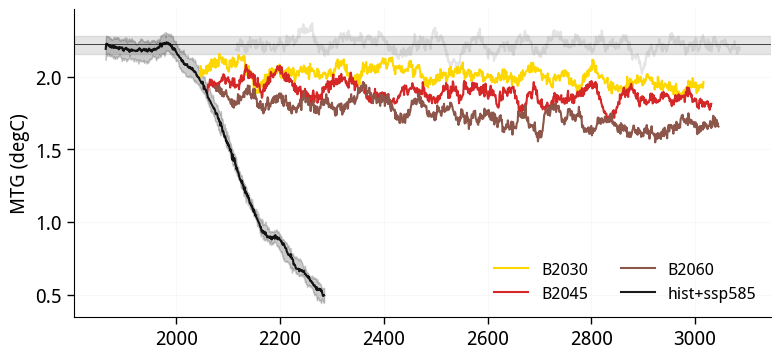

In [ ]:
plt.figure(figsize=(9,4))

xdata = rolling_mtg_pic.time.dt.year + 2000
plt.plot(xdata, rolling_mtg_pic, color='tab:gray', alpha=0.2)
plt.axhspan(rolling_mtg_pic.quantile(0.1, 'time'), rolling_mtg_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.2)
plt.axhline(rolling_mtg_pic.quantile(0.5, 'time'), color='k', lw=0.5)

plt.plot(rolling_mtg_stable.time.dt.year, rolling_mtg_stable.sel(model = '2030'), color='gold', lw=1.5, label='B2030')
# plt.axhline(rolling_mtg_stable.sel(model='B2030').quantile(0.5, dim='time'), color='gold')

plt.plot(rolling_mtg_stable.time.dt.year, rolling_mtg_stable.sel(model = '2045'), color='tab:red', lw=1.5, label='B2045')
# plt.axhline(rolling_mtg_stable.sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')

plt.plot(rolling_mtg_stable.time.dt.year, rolling_mtg_stable.sel(model = '2060'), color='tab:brown', lw=1.5, label='B2060')
# plt.axhline(rolling_mtg_stable.sel(model='B2060').quantile(0.5, dim='time'), color='tab:brown')

# plt.plot(rolling_mtg_trans.time.dt.year, rolling_mtg_trans.quantile(0.5, 'model'), color='k', lw=1.5, label='esm-hist+ssp585')
# plt.plot(rolling_mtg_trans.time.dt.year, rolling_mtg_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp585 r10')
# plt.fill_between(rolling_mtg_trans.time.dt.year, rolling_mtg_trans.quantile(0.1, 'model'), rolling_mtg_trans.quantile(0.9, 'model'), color='k', alpha=0.3)

plt.plot(conc_rolling_mtg_trans.time.dt.year, conc_rolling_mtg_trans.quantile(0.5, 'model'), color='k', lw=1.5, label='hist+ssp585', alpha=0.9)
# plt.plot(rolling_mtg_trans.time.dt.year, rolling_mtg_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp585 r10')
plt.fill_between(conc_rolling_mtg_trans.time.dt.year, conc_rolling_mtg_trans.quantile(0.1, 'model'), conc_rolling_mtg_trans.quantile(0.9, 'model'), color='k', alpha=0.2)

# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
# plt.ylim(-1.4, 0.5)
# sns.despine(left=True, trim=True)
# plt.yticks([])
# # plt.minorticks_on()
# # plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=12, loc='lower right', ncol=2)
# plt.axhline(0.0, color='k', lw=0.5)
plot_decorator()
plt.ylabel('MTG (degC)')
# plt.xlabel('Year')


Text(0.5, 0, 'MTG (degC)')

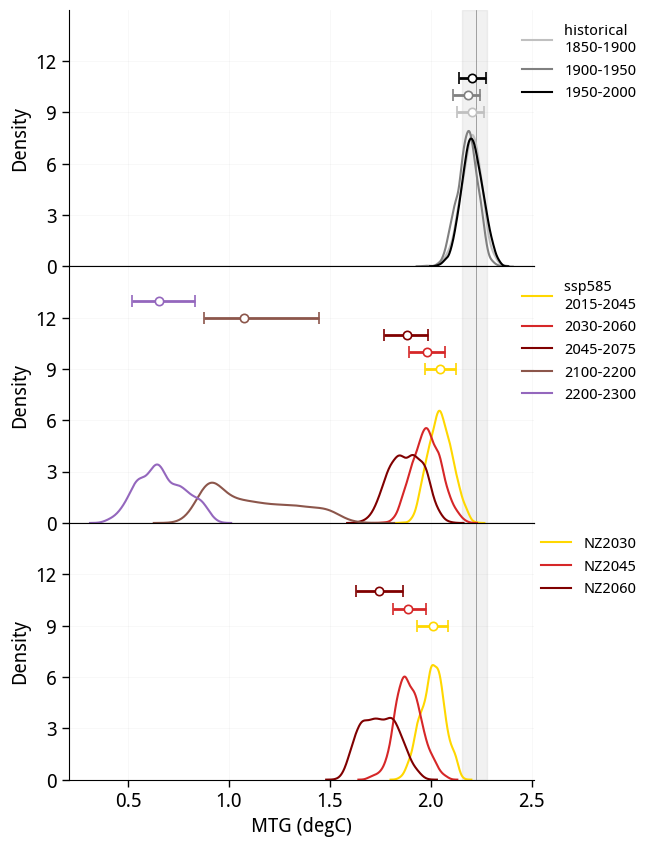

In [146]:
fig, axarr = plt.subplots(nrows=3, ncols=1, figsize=(6,10), constrained_layout=False, sharex=True, sharey=True)
axlist = axarr.flatten()


###
axlist[0].axvline(rolling_mtg_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[0].axvspan(rolling_mtg_pic.quantile(0.1, 'time'), rolling_mtg_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(np.ravel(conc_rolling_mtg_trans.sel(time = slice('1850', '1900'))), color='silver', ax=axlist[0], label='historical \n1850-1900')
sns.kdeplot(np.ravel(conc_rolling_mtg_trans.sel(time = slice('1900', '1950'))), color='gray', ax=axlist[0], label='1900-1950')
sns.kdeplot(np.ravel(conc_rolling_mtg_trans.sel(time = slice('1950', '2000'))), color='k', ax=axlist[0], label='1950-2000')
# axlist[0].axvline(np.mean(np.ravel(conc_rolling_mtg_trans.sel(time = slice('1850', '1900')))), color='k', lw=1.0)
plot_dist_inset(axlist[0], conc_rolling_mtg_trans.sel(time = slice('1850', '1900')), 9, color='silver', dim=(("time", "model")))
plot_dist_inset(axlist[0], conc_rolling_mtg_trans.sel(time = slice('1900', '1950')), 10, color='gray', dim=(("time", "model")))
plot_dist_inset(axlist[0], conc_rolling_mtg_trans.sel(time = slice('1950', '2000')), 11, color='k', dim=(("time", "model")))

###
axlist[1].axvline(rolling_mtg_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[1].axvspan(rolling_mtg_pic.quantile(0.1, 'time'), rolling_mtg_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)

sns.kdeplot(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2015', '2045'))), color='gold', ax=axlist[1], label='ssp585 \n2015-2045')
plot_dist_inset(axlist[1], conc_rolling_mtg_trans.sel(time = slice('2015', '2045')), 9, color='gold', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2015', '2045')))), color='gold', lw=1.0)

sns.kdeplot(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2030', '2060'))), color='tab:red', ax=axlist[1], label='2030-2060')
plot_dist_inset(axlist[1], conc_rolling_mtg_trans.sel(time = slice('2030', '2060')), 10, color='tab:red', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2030', '2060')))), color='tab:red', lw=1.0)

sns.kdeplot(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2045', '2075'))), color='maroon', ax=axlist[1], label='2045-2075')
plot_dist_inset(axlist[1], conc_rolling_mtg_trans.sel(time = slice('2045', '2075')), 11.0, color='maroon', dim=(("time", "model")))
# axlist[1].axvline(np.mean(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2045', '2075')))), color='maroon', lw=1.0)

sns.kdeplot(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2100', '2200'))), color='tab:brown', ax=axlist[1], label='2100-2200')
plot_dist_inset(axlist[1], conc_rolling_mtg_trans.sel(time = slice('2100', '2200')), 12, color='tab:brown', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2100', '2200')))), color='tab:brown', lw=1.0)

sns.kdeplot(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2200', '2300'))), color='tab:purple', ax=axlist[1], label='2200-2300')
plot_dist_inset(axlist[1], conc_rolling_mtg_trans.sel(time = slice('2200', '2300')), 13, color='tab:purple', dim=(("time", "model")))
# axlist[1].axvline(np.nanmean(np.ravel(conc_rolling_mtg_trans.sel(time = slice('2200', '2300')))), color='tab:purple', lw=1.0)

###
axlist[2].axvline(rolling_mtg_pic.quantile(0.5, 'time'), color='tab:gray', lw=0.5)
axlist[2].axvspan(rolling_mtg_pic.quantile(0.1, 'time'), rolling_mtg_pic.quantile(0.9, 'time'), color='tab:gray', alpha=0.1)
sns.kdeplot(rolling_mtg_stable.sel(model='2030'), color='gold', ax=axlist[2], label='NZ2030')
plot_dist_inset(axlist[2], rolling_mtg_stable.sel(model = '2030'), 9.0, color='gold', dim=(("time")))
# axlist[2].axvline(rolling_mtg_stable.sel(model = 'B2030').mean('time'), color='gold', lw=1.0)

sns.kdeplot(rolling_mtg_stable.sel(model='2045'), color='tab:red', ax=axlist[2], label='NZ2045')
plot_dist_inset(axlist[2], rolling_mtg_stable.sel(model = '2045'), 10, color='tab:red', dim=(("time")))
# axlist[2].axvline(rolling_mtg_stable.sel(model = 'B2045').mean('time'), color='tab:red', lw=1.0)

sns.kdeplot(rolling_mtg_stable.sel(model='2060'), color='maroon', ax=axlist[2], label='NZ2060')
plot_dist_inset(axlist[2], rolling_mtg_stable.sel(model = '2060'), 11, color='maroon', dim=(("time")))
# axlist[2].axvline(rolling_mtg_stable.sel(model = 'B2060').mean('time'), color='maroon', lw=1.0)

for ax in np.ravel(axlist):
#     # axlist[j].
#     pass
    ax.legend(frameon=False, fontsize=11, loc='upper right', bbox_to_anchor=(1.25, 1))
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    # ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# sns.despine(trim=True, bottom=False)
# sns.despine()
# plt.xticks([])
plt.ylim(0, 15)
# plt.xlim(-1.6, 0.2)
plt.gca().set_yticks(np.arange(0, 15, 3))
plt.subplots_adjust(wspace=0.0, hspace=0.0)
axlist[0].spines['top'].set_visible(False)
# plt.minorticks_on()
plt.xlabel('MTG (degC)')

Text(0.5, 1.0, 'piControl')

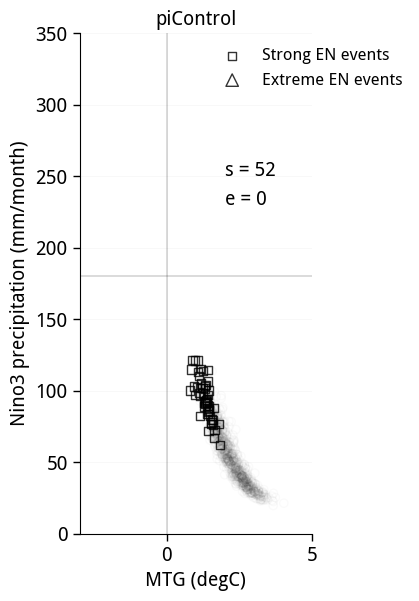

In [84]:
plt.figure(figsize=(3,6.5))
strong_cond = ((nino3_pic_index > 1.5*nino3_pic_index.std('time')) & (nino3_pr_pic < 180))
extreme_cond = ((nino3_pic_index > 1.5*nino3_pic_index.std('time')) & (nino3_pr_pic >= 180))
plt.scatter((nino3_north_pic - nino3_pic), nino3_pr_pic, color='k', alpha=0.02, facecolor='none')
plt.scatter((nino3_north_pic.where(strong_cond, drop=True) - nino3_pic.where(strong_cond, drop=True)).isel(time = slice(0, 900)), nino3_pr_pic.where(strong_cond, drop=True).isel(time = slice(0, 900)), marker='s', color='k', alpha=0.8, facecolor='none', label = 'Strong EN events')
plt.scatter((nino3_north_pic.where(extreme_cond, drop=True) - nino3_pic.where(extreme_cond, drop=True)).isel(time = slice(0, 900)), nino3_pr_pic.where(extreme_cond, drop=True).isel(time = slice(0, 900)), marker='^', s=80, color='k', alpha=0.8, facecolor='none', label = 'Extreme EN events')
plot_decorator()
plt.xlim(-3.0, 5.0)
plt.ylim(0, 350)
plt.xlabel('MTG (degC)')
plt.ylabel('Nino3 precipitation (mm/month)')
plt.axvline(0.0, color='k', lw=0.2)
plt.axhline(180.0, color='k', lw=0.2)
plt.legend(frameon=False, fontsize=12, bbox_to_anchor=(0.52, 1.0))
plt.text(2, 250, f's = {int(nino3_pr_pic.where(strong_cond, drop=True).isel(time = slice(0, 900)).count())}', fontdict=dict(size=14))
plt.text(2, 230, f'e = {int(nino3_pr_pic.where(extreme_cond, drop=True).isel(time = slice(0, 900)).count())}', fontdict=dict(size=14))

int(nino3_pic.isel(time = slice(0, 900)).time.count())
plt.title('piControl', fontsize=14)

In [73]:
conc_nino3_trans = conc_nino3_trans.sortby('model')
conc_nino3_trans_index = conc_nino3_trans_index.sortby('model')
conc_nino3_north_trans = conc_nino3_north_trans.sortby('model')
conc_nino3_pr_trans = conc_nino3_pr_trans.sortby('model')
conc_nino3_pr_trans['model'] = conc_nino3_trans['model']

In [74]:
conc_nino3_pr_trans

<xarray.DataArray 'pr' (model: 40, time: 452)> Size: 145kB
array([[ 67.94297395,  26.30715053,  86.65385074, ..., 296.67837515,
        278.59324593, 302.63899324],
       [ 92.20211611,  25.78060534,  48.21643433, ...,          nan,
                 nan,          nan],
       [ 96.23782406,  48.84066897,  45.10628689, ...,          nan,
                 nan,          nan],
       ...,
       [190.86142903,  49.16707372,  67.57413674, ..., 326.24812447,
        238.06367854, 304.96200725],
       [100.30889057,  37.03846756,  52.99322858, ..., 306.68034987,
        350.8779247 , 276.38305652],
       [ 41.40651173,  60.94033054,  44.08413489, ..., 191.21336344,
        404.09118272, 204.77662932]])
Coordinates:
  * time                (time) object 4kB 1849-06-01 00:00:00 ... 2300-06-01 ...
    latitude_longitude  float64 8B nan
  * model               (model) <U22 4kB 'ACCESS-ESM1-5_r10i1p1f' ... 'ACCESS...

Text(0.5, 1.0, 'ssp585 [2045-2075]')

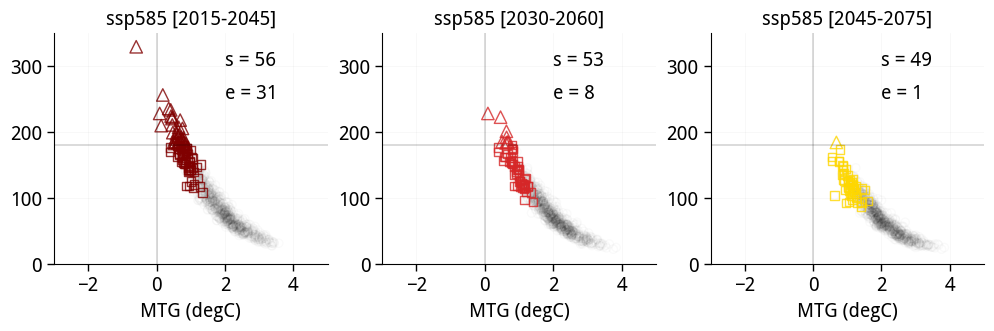

In [90]:
plt.figure(figsize=(12,3))

plt.subplot(131)
strong_cond = ((conc_nino3_trans_index > 1.5*conc_nino3_trans_index.std('time')) & (conc_nino3_pr_trans < 180))
extreme_cond = ((conc_nino3_trans_index > 1.5*conc_nino3_trans_index.std('time')) & (conc_nino3_pr_trans >= 180))

plt.scatter((conc_nino3_north_trans - conc_nino3_trans).sel(time = slice('2046', '2075')).isel(model = slice(0, 30)), conc_nino3_pr_trans.sel(time = slice('2046', '2075')).isel(model = slice(0, 30)), color='k', alpha=0.02, facecolor='none', label='All events')
plt.scatter((conc_nino3_north_trans.where(strong_cond, drop=True) - conc_nino3_trans.where(strong_cond, drop=True)).sel(time = slice('2046', '2075')).isel(model = slice(0, 30)), conc_nino3_pr_trans.where(strong_cond, drop=True).sel(time = slice('2046', '2075')).isel(model = slice(0, 30)), marker='s', color='maroon', alpha=0.8, facecolor='none', label = 'Strong EN events')
plt.scatter((conc_nino3_north_trans.where(extreme_cond, drop=True) - conc_nino3_trans.where(extreme_cond, drop=True)).sel(time = slice('2046', '2075')).isel(model = slice(0, 30)), conc_nino3_pr_trans.where(extreme_cond, drop=True).sel(time = slice('2046', '2075')).isel(model = slice(0, 30)), marker='^', s=80, color='maroon', alpha=0.8, facecolor='none', label = 'Extrme EN events')


plot_decorator()
plt.xlim(-3.0, 5.0)
plt.ylim(0, 350)
plt.xlabel('MTG (degC)')
# plt.ylabel('Nino3 precipitation (mm/month)')
plt.axvline(0.0, color='k', lw=0.2)
plt.axhline(180.0, color='k', lw=0.2)
val = int(conc_nino3_pr_trans.where(strong_cond, drop=True).sel(time = slice('2046', '2075')).isel(model = slice(0, 30)).count())
plt.text(2, 300, f's = {val}', fontdict=dict(size=14))
val = int(conc_nino3_pr_trans.where(extreme_cond, drop=True).sel(time = slice('2046', '2075')).isel(model = slice(0, 30)).count())
plt.text(2, 250, f'e = {val}', fontdict=dict(size=14))
plt.title('ssp585 [2015-2045]', fontsize=14)


# int(conc_nino3_trans.sel(time = slice('2046', '2075')).isel(model = slice(0, 30)).count())




plt.subplot(132)
strong_cond = ((conc_nino3_trans_index > 1.5*conc_nino3_trans_index.std('time')) & (conc_nino3_pr_trans < 180))
extreme_cond = ((conc_nino3_trans_index > 1.5*conc_nino3_trans_index.std('time')) & (conc_nino3_pr_trans >= 180))

plt.scatter((conc_nino3_north_trans - conc_nino3_trans).sel(time = slice('2031', '2060')).isel(model = slice(0, 30)), conc_nino3_pr_trans.sel(time = slice('2031', '2060')).isel(model = slice(0, 30)), color='k', alpha=0.02, facecolor='none', label='All events')
plt.scatter((conc_nino3_north_trans.where(strong_cond, drop=True) - conc_nino3_trans.where(strong_cond, drop=True)).sel(time = slice('2031', '2060')).isel(model = slice(0, 30)), conc_nino3_pr_trans.where(strong_cond, drop=True).sel(time = slice('2031', '2060')).isel(model = slice(0, 30)), marker='s', color='tab:red', alpha=0.8, facecolor='none', label = 'Strong EN events')
plt.scatter((conc_nino3_north_trans.where(extreme_cond, drop=True) - conc_nino3_trans.where(extreme_cond, drop=True)).sel(time = slice('2031', '2060')).isel(model = slice(0, 30)), conc_nino3_pr_trans.where(extreme_cond, drop=True).sel(time = slice('2031', '2060')).isel(model = slice(0, 30)), marker='^', s=80, color='tab:red', alpha=0.8, facecolor='none', label = 'Extrme EN events')


plot_decorator()
plt.xlim(-3.0, 5.0)
plt.ylim(0, 350)
plt.xlabel('MTG (degC)')
# plt.ylabel('Nino3 precipitation (mm/month)')
plt.axvline(0.0, color='k', lw=0.2)
plt.axhline(180.0, color='k', lw=0.2)
val = int(conc_nino3_pr_trans.where(strong_cond, drop=True).sel(time = slice('2031', '2060')).isel(model = slice(0, 30)).count())
plt.text(2, 300, f's = {val}', fontdict=dict(size=14))
val = int(conc_nino3_pr_trans.where(extreme_cond, drop=True).sel(time = slice('2031', '2060')).isel(model = slice(0, 30)).count())
plt.text(2, 250, f'e = {val}', fontdict=dict(size=14))
plt.title('ssp585 [2030-2060]', fontsize=14)

# int(conc_nino3_trans.sel(time = slice('2031', '2060')).isel(model = slice(0, 30)).count())


plt.subplot(133)
strong_cond = ((conc_nino3_trans_index > 1.5*conc_nino3_trans_index.std('time')) & (conc_nino3_pr_trans < 180))
extreme_cond = ((conc_nino3_trans_index > 1.5*conc_nino3_trans_index.std('time')) & (conc_nino3_pr_trans >= 180))

plt.scatter((conc_nino3_north_trans - conc_nino3_trans).sel(time = slice('2016', '2045')).isel(model = slice(0, 30)), conc_nino3_pr_trans.sel(time = slice('2016', '2045')).isel(model = slice(0, 30)), color='k', alpha=0.02, facecolor='none', label='All events')
plt.scatter((conc_nino3_north_trans.where(strong_cond, drop=True) - conc_nino3_trans.where(strong_cond, drop=True)).sel(time = slice('2016', '2045')).isel(model = slice(0, 30)), conc_nino3_pr_trans.where(strong_cond, drop=True).sel(time = slice('2016', '2045')).isel(model = slice(0, 30)), marker='s', color='gold', alpha=0.8, facecolor='none', label = 'Strong EN events')
plt.scatter((conc_nino3_north_trans.where(extreme_cond, drop=True) - conc_nino3_trans.where(extreme_cond, drop=True)).sel(time = slice('2016', '2045')).isel(model = slice(0, 30)), conc_nino3_pr_trans.where(extreme_cond, drop=True).sel(time = slice('2016', '2045')).isel(model = slice(0, 30)), marker='^', s=80, color='gold', alpha=0.8, facecolor='none', label = 'Extrme EN events')


plot_decorator()
plt.xlim(-3.0, 5.0)
plt.ylim(0, 350)
plt.xlabel('MTG (degC)')
# plt.ylabel('Nino3 precipitation (mm/month)')
plt.axvline(0.0, color='k', lw=0.2)
plt.axhline(180.0, color='k', lw=0.2)
val = int(conc_nino3_pr_trans.where(strong_cond, drop=True).sel(time = slice('2016', '2045')).isel(model = slice(0, 30)).count())
plt.text(2, 300, f's = {val}', fontdict=dict(size=14))
val = int(conc_nino3_pr_trans.where(extreme_cond, drop=True).sel(time = slice('2016', '2045')).isel(model = slice(0, 30)).count())
plt.text(2, 250, f'e = {val}', fontdict=dict(size=14))
plt.title('ssp585 [2045-2075]', fontsize=14)

# plt.subplots_adjust(hspace=0.6)

# int(conc_nino3_trans.sel(time = slice('2016', '2045')).isel(model = slice(0, 30)).count())

In [55]:
nino3_stable = nino3_stable.sortby('model')
nino3_stable_index = nino3_stable_index.sortby('model')
nino3_north_stable = nino3_north_stable.sortby('model')
nino3_pr_stable = nino3_pr_stable.sortby('model')
nino3_pr_stable['model'] = nino3_stable.sortby('model')['model']
nino3_pr_stable['time'] = nino3_stable['time']

# nino3_stable = nino3_stable.sel(time = slice('2031', '3059'))
# nino3_north_stable = nino3_north_stable.sel(time = slice('2031', '3059'))
# nino3_pr_stable = nino3_pr_stable.sel(time = slice('2031', '3059'))

Text(0.5, 1.0, 'NZ B2030')

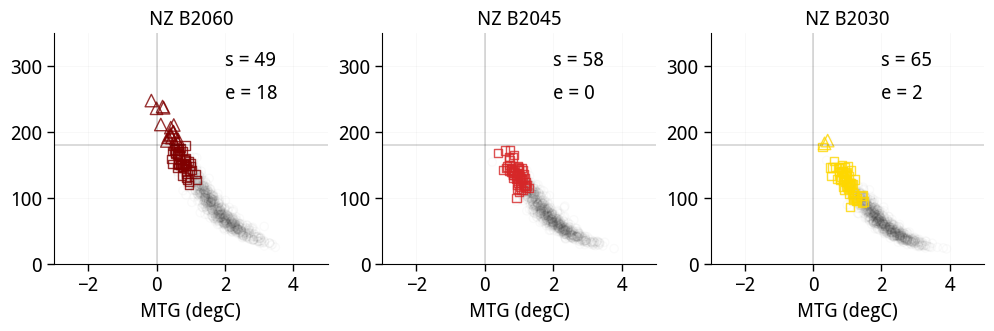

In [93]:
plt.figure(figsize=(12,3))


plt.subplot(131)
strong_cond = ((nino3_stable_index > 1.5*nino3_stable_index.std('time')) & (nino3_pr_stable < 180))
extreme_cond = ((nino3_stable_index > 1.5*nino3_stable_index.std('time')) & (nino3_pr_stable >= 180))

plt.scatter((nino3_north_stable - nino3_stable).sel(model='2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)), nino3_pr_stable.sel(model = '2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)), color='k', alpha=0.02, facecolor='none')
plt.scatter((nino3_north_stable.where(strong_cond, drop=True) - nino3_stable.where(strong_cond, drop=True)).sel(model = '2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)), nino3_pr_stable.where(strong_cond, drop=True).sel(model='2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)), marker='s', color='maroon', alpha=0.8, facecolor='none', label = 'Strong EN events')
plt.scatter((nino3_north_stable.where(extreme_cond, drop=True) - nino3_stable.where(extreme_cond, drop=True)).sel(model = '2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)), nino3_pr_stable.where(extreme_cond, drop=True).sel(model = '2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)), marker='^', s=80, color='maroon', alpha=0.8, facecolor='none', label = 'Extrme EN events')

plot_decorator()
plt.xlim(-3, 5)
plt.ylim(0, 350)
plt.xlabel('MTG (degC)')
plt.axvline(0.0, color='k', lw=0.2)
plt.axhline(180, color='k', lw=0.2)
# plt.ylabel('Nino3 precipitation (degC)')
val = int(nino3_pr_stable.where(strong_cond, drop=True).sel(model='2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)).count())
plt.text(2, 300, f's = {val}', fontdict=dict(size=14))
val = int(nino3_pr_stable.where(extreme_cond, drop=True).sel(model='2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)).count())
plt.text(2, 250, f'e = {val}', fontdict=dict(size=14))
plt.title('NZ B2060', fontsize=14)

# int(nino3_pr_stable.sel(model = '2060').sel(time = slice('2060', '3060')).isel(time = slice(0, 900)).count())


plt.subplot(132)
strong_cond = ((nino3_stable_index > 1.5*nino3_stable_index.std('time')) & (nino3_pr_stable < 180))
extreme_cond = ((nino3_stable_index > 1.5*nino3_stable_index.std('time')) & (nino3_pr_stable >= 180))

plt.scatter((nino3_north_stable - nino3_stable).sel(model='2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)), nino3_pr_stable.sel(model = '2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)), color='k', alpha=0.02, facecolor='none')
plt.scatter((nino3_north_stable.where(strong_cond, drop=True) - nino3_stable.where(strong_cond, drop=True)).sel(model = '2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)), nino3_pr_stable.where(strong_cond, drop=True).sel(model='2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)), marker='s', color='tab:red', alpha=0.8, facecolor='none', label = 'Strong EN events')
plt.scatter((nino3_north_stable.where(extreme_cond) - nino3_stable.where(extreme_cond)).sel(model = '2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)), nino3_pr_stable.where(extreme_cond).sel(model = '2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)), marker='^', s=80, color='tab:red', alpha=0.8, facecolor='none', label = 'Extrme EN events')

plot_decorator()
plt.xlim(-3, 5)
plt.ylim(0, 350)
plt.xlabel('MTG (degC)')
plt.axvline(0.0, color='k', lw=0.2)
plt.axhline(180, color='k', lw=0.2)
# plt.ylabel('Nino3 precipitation (degC)')
val = int(nino3_pr_stable.where(strong_cond, drop=True).sel(model='2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)).count())
plt.text(2, 300, f's = {val}', fontdict=dict(size=14))
val = int(nino3_pr_stable.where(extreme_cond).sel(model='2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)).count())
plt.text(2, 250, f'e = {val}', fontdict=dict(size=14))
plt.title('NZ B2045', fontsize=14)

# int(nino3_pr_stable.sel(model = '2045').sel(time = slice('2045', '3045')).isel(time = slice(0, 900)).count())


plt.subplot(133)
strong_cond = ((nino3_stable_index > 1.5*nino3_stable_index.std('time')) & (nino3_pr_stable < 180))
extreme_cond = ((nino3_stable_index > 1.5*nino3_stable_index.std('time')) & (nino3_pr_stable >= 180))

plt.scatter((nino3_north_stable - nino3_stable).sel(model='2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)), nino3_pr_stable.sel(model = '2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)), color='k', alpha=0.02, facecolor='none')
plt.scatter((nino3_north_stable.where(strong_cond, drop=True) - nino3_stable.where(strong_cond, drop=True)).sel(model = '2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)), nino3_pr_stable.where(strong_cond, drop=True).sel(model='2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)), marker='s', color='gold', alpha=0.8, facecolor='none', label = 'Strong EN events')
plt.scatter((nino3_north_stable.where(extreme_cond, drop=True) - nino3_stable.where(extreme_cond, drop=True)).sel(model = '2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)), nino3_pr_stable.where(extreme_cond, drop=True).sel(model = '2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)), marker='^', s=80, color='gold', alpha=0.8, facecolor='none', label = 'Extrme EN events')

plot_decorator()
plt.xlim(-3, 5)
plt.ylim(0, 350)
plt.xlabel('MTG (degC)')
plt.axvline(0.0, color='k', lw=0.2)
plt.axhline(180, color='k', lw=0.2)
# plt.ylabel('Nino3 precipitation (degC)')
val = int(nino3_pr_stable.where(strong_cond, drop=True).sel(model='2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)).count())
plt.text(2, 300, f's = {val}', fontdict=dict(size=14))
val = int(nino3_pr_stable.where(extreme_cond, drop=True).sel(model='2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)).count())
plt.text(2, 250, f'e = {val}', fontdict=dict(size=14))
plt.title('NZ B2030', fontsize=14)

# int(nino3_pr_stable.sel(model = '2030').sel(time = slice('2030', '3030')).isel(time = slice(0, 900)).count())

In [94]:
gmst_trans = ts_trans.weighted(weights_model).mean(('lat', 'lon')).isel(time = slice(100, -1))

In [95]:
gmst_stable = ts_stable.weighted(weights_model).mean(('lat', 'lon'))

In [96]:
conc_gmst_trans = conc_ts_trans.weighted(weights_model).mean(('lat', 'lon')).isel(time = slice(100, -1))

In [97]:
ts_1pct_access_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/ACCESS-ESM1-5_1pctco2_tas.nc').tas
ts_pic_access_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/ACCESS-ESM1-5_pic_tas.nc').tas
ts_1pct_access = funcs.calc_anom_annual(ts_1pct_access_orig, ts_pic_access_orig)
gmst_1pct = ts_1pct_access.weighted(weights_model).mean(('lat', 'lon'))

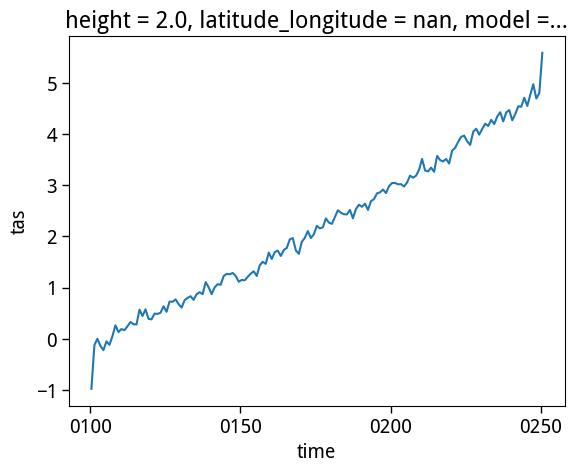

In [98]:
gmst_1pct.plot()

In [ ]:
nino3_1pct = funcs.detrend_rolling_window(ts_1pct_access.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)

In [119]:
sst_grad_1pct = ts_1pct_access_orig.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - ts_1pct_access_orig.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon'))

Text(0.5, 0, 'GMST anomaly (degC)')

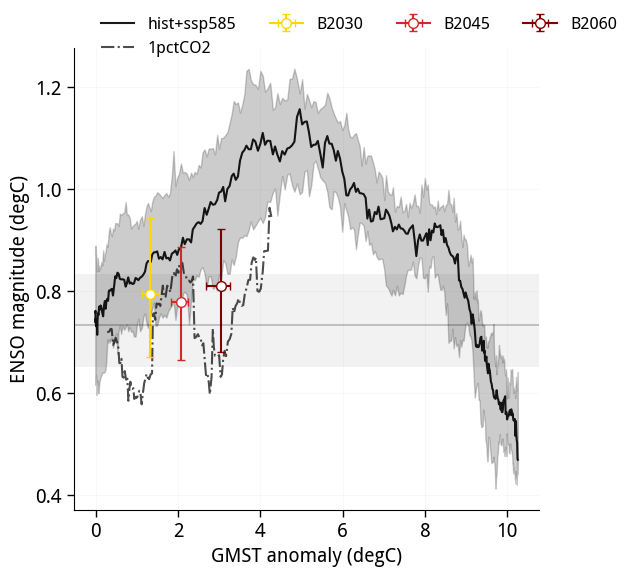

In [113]:
plt.figure(figsize=(6,6))
# plt.plot(gmst_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), nino3_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.5, 'model'), color='k')
plt.plot(conc_gmst_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), conc_nino3_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.5, 'model'), color='k', alpha=0.9, label='hist+ssp585')
plt.fill_between(conc_gmst_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), conc_nino3_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.1, 'model'),conc_nino3_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.9, 'model'), color='k', alpha=0.2)
plt.plot(gmst_1pct.rolling(time = 30, center=True).mean('time').isel(model=0), nino3_1pct.rolling(time = 30, center=True).std('time').isel(model=0), color='k', alpha=0.7, ls='-.', label='1pctCO2')

xval = gmst_stable.sel(model = '2030').rolling(time = 30, center=True).mean('time')
yval = nino3_stable.sel(model = '2030').rolling(time = 30, center=True).std('time')
plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='gold', label='B2030')

xval = gmst_stable.sel(model = '2045').rolling(time = 30, center=True).mean('time')
yval = nino3_stable.sel(model = '2045').rolling(time = 30, center=True).std('time')
plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='tab:red', label='B2045')

xval = gmst_stable.sel(model = '2060').rolling(time = 30, center=True).mean('time')
yval = nino3_stable.sel(model = '2060').rolling(time = 30, center=True).std('time')
plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='maroon', label='B2060')

plt.axhline(nino3_mag_pic.quantile(0.5, 'time'), color='k', lw=0.3)
plt.axhspan(nino3_mag_pic.quantile(0.1, 'time'), nino3_mag_pic.quantile(0.9, 'time'), color='k', alpha=0.05, lw=0.)

plot_decorator()
plt.legend(frameon=False, fontsize=12, loc='upper right', ncol=4, bbox_to_anchor=(1.2,1.1))
plt.ylabel('ENSO magnitude (degC)')
plt.xlabel('GMST anomaly (degC)')

(1.0, 4.0)

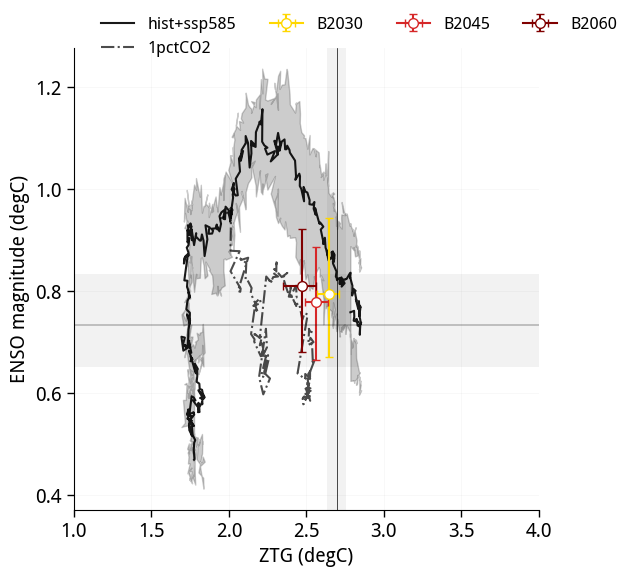

In [125]:
plt.figure(figsize=(6,6))
# plt.plot(gmst_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), nino3_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.5, 'model'), color='k')
plt.plot(conc_sst_grad_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), conc_nino3_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.5, 'model'), color='k', alpha=0.9, label='hist+ssp585')
plt.fill_between(conc_sst_grad_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), conc_nino3_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.1, 'model'),conc_nino3_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.9, 'model'), color='k', alpha=0.2)
plt.plot(sst_grad_1pct.rolling(time = 30, center=True).mean('time').isel(model=0), nino3_1pct.rolling(time = 30, center=True).std('time').isel(model=0), color='k', alpha=0.7, ls='-.', label='1pctCO2')

xval = sst_grad_stable.sel(model = '2030').rolling(time = 30, center=True).mean('time')
yval = nino3_stable.sel(model = '2030').rolling(time = 30, center=True).std('time')
plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='gold', label='B2030')

xval = sst_grad_stable.sel(model = '2045').rolling(time = 30, center=True).mean('time')
yval = nino3_stable.sel(model = '2045').rolling(time = 30, center=True).std('time')
plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='tab:red', label='B2045')

xval = sst_grad_stable.sel(model = '2060').rolling(time = 30, center=True).mean('time')
yval = nino3_stable.sel(model = '2060').rolling(time = 30, center=True).std('time')
plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='maroon', label='B2060')

plt.axhline(nino3_mag_pic.quantile(0.5, 'time'), color='k', lw=0.3)
plt.axhspan(nino3_mag_pic.quantile(0.1, 'time'), nino3_mag_pic.quantile(0.9, 'time'), color='k', alpha=0.05, lw=0.)
plt.axvline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='k', lw=0.5)
plt.axvspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='k', alpha=0.05, lw=0.)

plot_decorator()
plt.legend(frameon=False, fontsize=12, loc='upper right', ncol=4, bbox_to_anchor=(1.2,1.1))
plt.ylabel('ENSO magnitude (degC)')
plt.xlabel('ZTG (degC)')
plt.xlim(1, 4)

Text(0.5, 0, 'GMST anomaly (degC)')

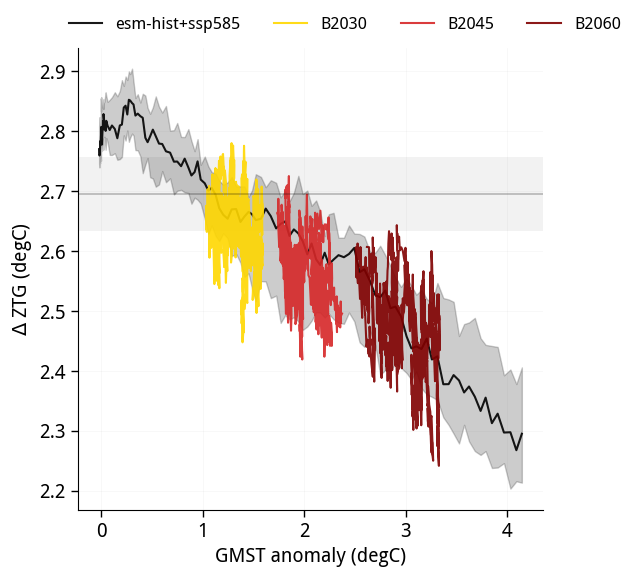

In [116]:
plt.figure(figsize=(6,6))
# plt.plot(gmst_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model'), nino34_trans.isel(time = slice(100, -1)).rolling(time = 30, center=True).std('time').quantile(0.5, 'model'), color='k')
plt.plot(gmst_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model')[15:-15], rolling_sst_grad_trans.isel(time = slice(100, -1)).quantile(0.5, 'model'), color='k', alpha=0.9, label='esm-hist+ssp585')
plt.fill_between(gmst_trans.rolling(time = 30, center=True).mean('time').quantile(0.5, 'model')[15:-15], rolling_sst_grad_trans.isel(time = slice(100, -1)).quantile(0.1, 'model'), rolling_sst_grad_trans.isel(time = slice(100, -1)).quantile(0.9, 'model'), color='k', alpha=0.2)

xval = gmst_stable.sel(model = '2030').rolling(time = 30, center=True).mean('time')
yval = rolling_sst_grad_stable.sel(model = '2030')
plt.plot(xval[15:-15], yval, color='gold', alpha=0.9, label='B2030')
# plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='gold', label='B2030')

xval = gmst_stable.sel(model = '2045').rolling(time = 30, center=True).mean('time')
yval = rolling_sst_grad_stable.sel(model = '2045')
plt.plot(xval[15:-15], yval, color='tab:red', alpha=0.9, label='B2045')
# plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='tab:red', label='B2045')

xval = gmst_stable.sel(model = '2060').rolling(time = 30, center=True).mean('time')
yval = rolling_sst_grad_stable.sel(model = '2060')
plt.plot(xval[15:-15], yval, color='maroon', alpha=0.9, label='B2060')
# plt.errorbar(xval.quantile(0.5, 'time'), yval.quantile(0.5, 'time'), xerr=[[xval.quantile(0.5, 'time')-xval.quantile(0.1, 'time')], [xval.quantile(0.9, 'time')-xval.quantile(0.5, 'time')]], yerr=[[yval.quantile(0.5, 'time')-yval.quantile(0.1, 'time')], [yval.quantile(0.9, 'time')-yval.quantile(0.5, 'time')]], marker='o', markersize=7, capsize=3, mfc='white', color='maroon', label='B2060')

plt.axhline(rolling_sst_grad_pic.quantile(0.5, 'time'), color='k', lw=0.3)
plt.axhspan(rolling_sst_grad_pic.quantile(0.1, 'time'), rolling_sst_grad_pic.quantile(0.9, 'time'), color='k', alpha=0.05, lw=0.)

plot_decorator()
plt.legend(frameon=False, fontsize=12, loc='upper right', ncol=4, bbox_to_anchor=(1.2,1.1))
plt.ylabel('$\Delta$ ZTG (degC)')
plt.xlabel('GMST anomaly (degC)')

In [74]:
nino34_trans

<xarray.DataArray 'ts' (model: 10, time: 252)>
array([[-2.17000510e-01,  6.11574907e-01,  6.50353035e-02, ...,
         4.95639089e-01,  2.57517801e+00, -6.36233532e-01],
       [-2.11359263e-03,  4.34059542e-01,  8.18815440e-01, ...,
         1.42800713e+00, -1.14889314e+00,  1.30739473e-01],
       [ 1.94568555e-01, -3.03460515e-01, -5.84350729e-01, ...,
         1.35130181e+00,  2.54227852e+00, -1.35354257e+00],
       ...,
       [-2.20444650e-01, -5.07404666e-02, -1.39780565e-01, ...,
         5.29600163e-01, -1.25919761e+00,  2.75618406e-01],
       [ 6.13306668e-02,  2.83578586e-01, -1.30656846e+00, ...,
        -3.68603744e+00, -6.48404654e-01,  9.61940521e-01],
       [ 5.17592644e-01, -1.04418140e+00, -1.99167878e-01, ...,
        -7.98174121e-02, -1.43354186e-01, -1.06849047e-01]])
Coordinates:
  * time                (time) object 1849-06-01 00:00:00 ... 2100-06-01 00:0...
  * model               (model) object 'ACCESS-ESM1-5_r10i1p1f' ... 'ACCESS-E...
    latitude_longitude  (time) float64 nan nan nan nan nan ... nan nan nan nan
    month               (time) int64 6 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6 6

## ENSO periodicity

In [ ]:
from scipy.signal import welch
from scipy.stats import chi2
import numpy as np

def compute_psd(index, fs=1, nperseg=None, alpha=0.95):
    """
    Compute Welch PSD with AR(1) and white-noise significance,
    and normalized power.

    Returns
    -------
    periods : ndarray
        Periods corresponding to PSD.
    psd_norm : ndarray
        Normalized PSD.
    psd_ar1_norm : ndarray
        Normalized AR(1) significance spectrum.
    psd_wn_norm : float
        Normalized white-noise significance.
    """
    index = np.asarray(index).flatten()
    N = len(index)
    if nperseg is None:
        nperseg = N // 2

    f, Pxx = welch(index, fs=fs, window="hann", nperseg=nperseg, scaling="density")
    mask = f > 0
    f = f[mask]
    psd = Pxx[mask]
    periods = 1 / f

    # normalize PSD by variance
    psd_norm = psd / np.var(index)

    # AR(1 significance
    r1 = np.corrcoef(index[:-1], index[1:])[0,1]
    psd_ar1 = (1 - r1**2) / (1 + r1**2 - 2*r1*np.cos(2*np.pi*f/fs))
    psd_ar1 *= chi2.ppf(alpha, df=2) / 2
    psd_ar1_norm = psd_ar1  # already relative to variance=1

    # White-noise significance
    psd_wn_norm = chi2.ppf(alpha, df=2) / 2

    return periods, psd_norm, psd_ar1_norm, psd_wn_norm




def morlet_wavelet_spectrum_coi(x, dt=1, dj=0.25, s0=2, J=None):
    """
    Compute Morlet wavelet spectrum with COI and normalized power.
    """
    x = np.asarray(x).flatten()
    N = len(x)
    t = np.arange(N) * dt
    x = (x - np.mean(x)) / np.std(x)

    if J is None:
        J = int(np.log2(N*dt/s0) / dj)

    scales = s0 * 2 ** (np.arange(0, J+1) * dj)
    periods = scales.copy()

    # Fourier frequencies
    k = np.fft.fftfreq(N, d=dt) * 2*np.pi
    f = np.fft.fft(x)

    wave = np.zeros((len(scales), N), dtype=complex)

    for i, s in enumerate(scales):
        norm = (dt / s**0.5) * (np.pi**-0.25)
        # Morlet daughter in Fourier space
        expnt = -0.5 * (s * k - 6)**2
        daughter = norm * np.exp(expnt)
        wave[i, :] = np.fft.ifft(f * daughter)

    power = np.abs(wave)**2
    # power_norm = power / np.var(x)
    power_norm = power#/ np.max(power)

    # COI (1D, length N)
    coi = dt * np.minimum(np.arange(N), N - np.arange(N))
    coi = coi * 2**0.5

    return power_norm, scales, periods, t, coi



def generate_spectrum_ensemble(nino34_ds):
    # Define common grids
    common_periods = np.logspace(np.log10(0.5), np.log10(100), 200)  # PSD
    common_scales = np.logspace(np.log10(2), np.log10(50), 100)      # Morlet
    
    # Precompute max time length across all models
    max_time = max(len(nino34_ds.isel(model=i).time.dropna('time')) 
                   for i in range(nino34_ds.model.size))

    # Initialize lists
    psd_list, psd_ar1_list, psd_wn_list = [], [], []
    morlet_list = []
    coi_list = []

    for i in range(nino34_ds.model.size):
        # Extract 1D NumPy array of the time series
        ts = nino34_ds.isel(model=i).dropna('time').values.flatten()
        N = len(ts)
        if N < 5:
            continue  # skip very short series

        # ---- PSD ----
        periods, psd_norm, psd_ar1_norm, psd_wn_norm = compute_psd(ts)

        # Interpolate PSD to common periods
        psd_interp = np.interp(common_periods, periods[::-1], psd_norm[::-1])
        psd_ar1_interp = np.interp(common_periods, periods[::-1], psd_ar1_norm[::-1])
        psd_wn_interp = np.full_like(common_periods, psd_wn_norm)

        psd_list.append(psd_interp)
        psd_ar1_list.append(psd_ar1_interp)
        psd_wn_list.append(psd_wn_interp)

        # ---- Morlet ----
        power_norm, scales, periods_m, t, coi = morlet_wavelet_spectrum_coi(ts)

        # Interpolate Morlet power to common scales
        power_interp_scales = np.zeros((len(common_scales), power_norm.shape[1]))
        for j, s in enumerate(common_scales):
            idx = np.argmin(np.abs(scales - s))
            power_interp_scales[j, :] = power_norm[idx, :]

        # Interpolate Morlet power to common max_time
        x_old = np.linspace(0, 1, power_interp_scales.shape[1])
        x_new = np.linspace(0, 1, max_time)
        power_interp = np.zeros((len(common_scales), max_time))
        for j in range(len(common_scales)):
            power_interp[j, :] = np.interp(x_new, x_old, power_interp_scales[j, :])
        morlet_list.append(power_interp)

    # Interpolate COI to common max_time
    x_old = np.linspace(0, 1, len(coi))
    coi_interp = np.interp(x_new, x_old, coi)
    coi_list.append(coi_interp)

    psd_ensemble = np.array(psd_list)        # shape: (n_models, n_periods)
    psd_ar1_ensemble = np.array(psd_ar1_list)
    psd_wn_ensemble = np.array(psd_wn_list)

    morlet_ensemble = np.array(morlet_list)  # shape: (n_models, n_scales, n_time_max)
    coi_ensemble = np.array(coi_list)
    return psd_ensemble, psd_ar1_ensemble, psd_wn_ensemble, morlet_ensemble, coi_ensemble, common_periods, common_scales, max_time

    # PSD ensemble mean and spread
    # psd_mean_pic = np.mean(psd_ensemble, axis=0)
    # psd_std_pic = np.std(psd_ensembl, axis=0)

    # # Morlet ensemble mean (ignoring varying lengths for now)
    # morlet_mean_pic = np.mean(morlet_ensemble, axis=0)
    # morlet_std_pic = np.std(morlet_ensemble, axis=0)

    # # Average COI across ensemble (make sure you collected this earlier!)
    # coi_mean_pic = np.mean(np.vstack(coi_list), axis=0)

In [ ]:
psd_ensemble_pic, psd_ar1_ensemble_pic, psd_wn_ensemble_pic, morlet_ensemble_pic, coi_ensemble_pic, common_periods, common_scales, max_time =  generate_spectrum_ensemble(additional_sampling_stabilisation_nomeans(nino34_pic, initiator=0, spacer=50))

Done


In [ ]:
# PSD ensemble mean and spread
psd_mean_pic = np.mean(psd_ensemble_pic, axis=0)
psd_std_pic = np.std(psd_ensemble_pic, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_pic = np.mean(morlet_ensemble_pic, axis=0)
morlet_std_pic = np.std(morlet_ensemble_pic, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_pic = np.mean(np.vstack(coi_ensemble_pic), axis=0)

In [ ]:
import matplotlib.ticker as ticker

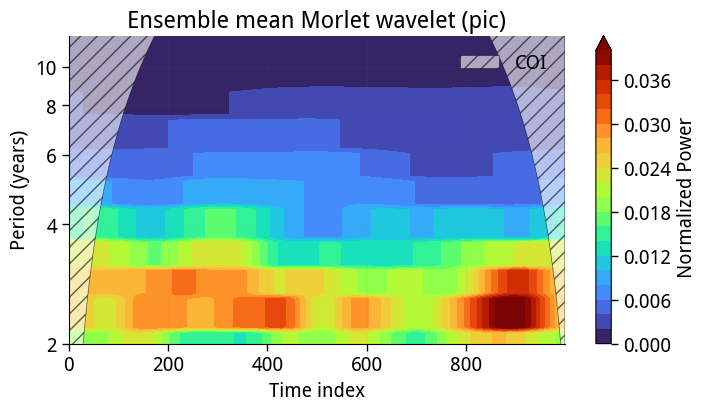

In [ ]:
cutoff_shape = 1000
T, S = np.meshgrid(np.arange(morlet_mean_pic[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_pic[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.04, levels= np.arange(0, 0.042, 0.002), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_pic[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (pic)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [ ]:
psd_ensemble_trans, psd_ar1_ensemble_trans, psd_wn_ensemble_trans, morlet_ensemble_trans, coi_ensemble_trans, common_periods, common_scales, max_time =  generate_spectrum_ensemble(nino34_trans.isel(time = slice(0, 250)))

In [ ]:
# PSD ensemble mean and spread
psd_mean_trans = np.mean(psd_ensemble_trans, axis=0)
psd_std_trans = np.std(psd_ensemble_trans, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_trans = np.mean(morlet_ensemble_trans, axis=0)
morlet_std_trans = np.std(morlet_ensemble_trans, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_trans = np.mean(np.vstack(coi_ensemble_trans), axis=0)

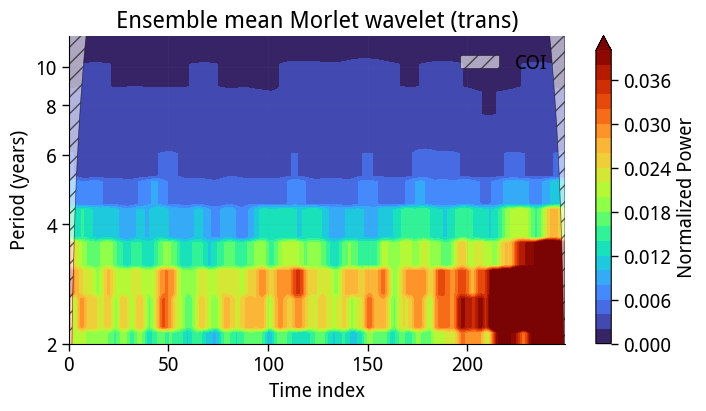

In [ ]:
cutoff_shape = 250
T, S = np.meshgrid(np.arange(morlet_mean_trans[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_trans[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.04, levels= np.arange(0, 0.042, 0.002), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_trans[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (trans)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [ ]:
psd_ensemble_stable, psd_ar1_ensemble_stable, psd_wn_ensemble_stable, morlet_ensemble_stable, coi_ensemble_stable, common_periods, common_scales, max_time =  generate_spectrum_ensemble(additional_sampling_stabilisation_nomeans(nino34_stable.sel(model = 'B2060'), initiator=0, spacer=50))

Done


In [ ]:
# PSD ensemble mean and spread
psd_mean_stable = np.mean(psd_ensemble_stable, axis=0)
psd_std_stable = np.std(psd_ensemble_stable, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_stable = np.mean(morlet_ensemble_stable, axis=0)
morlet_std_stable = np.std(morlet_ensemble_stable, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_stable = np.mean(np.vstack(coi_ensemble_stable), axis=0)

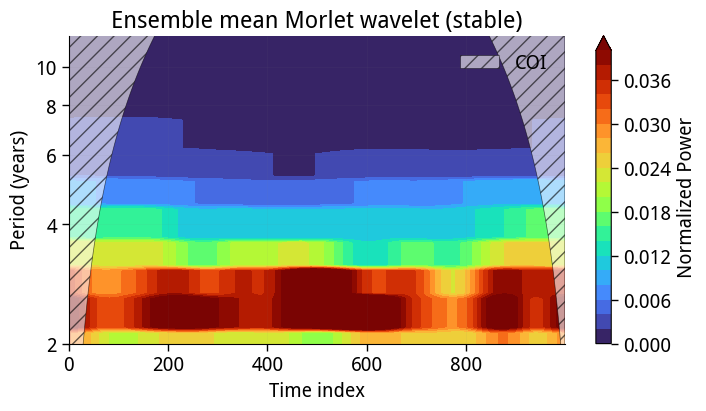

In [ ]:
cutoff_shape = 1000
T, S = np.meshgrid(np.arange(morlet_mean_stable[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_stable[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.04, levels= np.arange(0, 0.042, 0.002), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [ ]:
morlet_anomaly_trans = morlet_mean_trans - np.mean(morlet_mean_pic[:, :1000], axis=1).reshape(100, 1).repeat(250, 1)

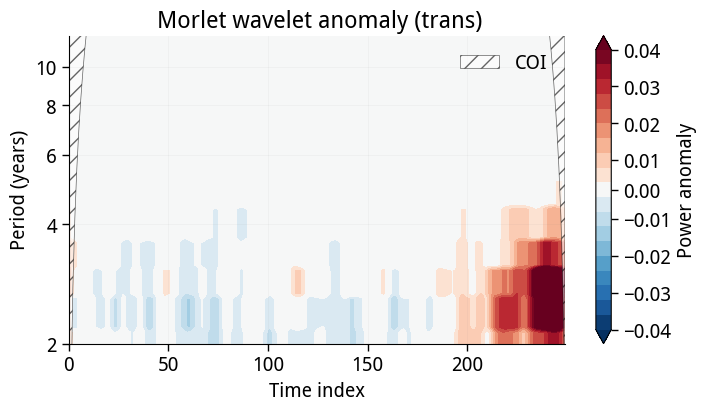

In [ ]:
cutoff_shape = 250
T, S = np.meshgrid(np.arange(morlet_anomaly_trans[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_trans[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.04, vmax=0.04, levels= np.concatenate((np.arange(-0.04, 0, 0.004), np.arange(0.004, 0.044, 0.004))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.04, 0.05, 0.01))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_trans[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (trans)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [ ]:
morlet_anomaly_stable = morlet_mean_stable - np.mean(morlet_mean_pic[:, :1000], axis=1).reshape(100, 1).repeat(1000, 1)

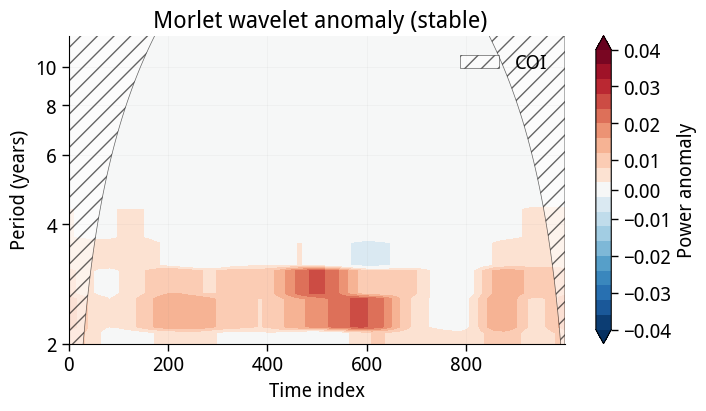

In [ ]:
cutoff_shape = 1000
T, S = np.meshgrid(np.arange(morlet_anomaly_stable[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_stable[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.04, vmax=0.04, levels= np.concatenate((np.arange(-0.04, 0, 0.004), np.arange(0.004, 0.044, 0.004))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.04, 0.05, 0.01))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [ ]:
morlet_anomaly_stable1 = morlet_mean_stable - np.mean(morlet_mean_trans[:, :250], axis=1).reshape(100, 1).repeat(1000, 1)

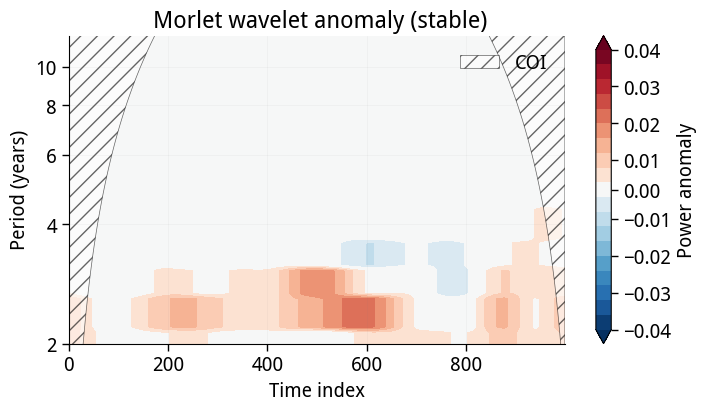

In [ ]:
cutoff_shape = 1000
T, S = np.meshgrid(np.arange(morlet_anomaly_stable1[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_stable1[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.04, vmax=0.04, levels= np.concatenate((np.arange(-0.04, 0, 0.004), np.arange(0.004, 0.044, 0.004))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.04, 0.05, 0.01))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [ ]:
np.shape(morlet_ensemble_pic)

(20, 100, 1000)

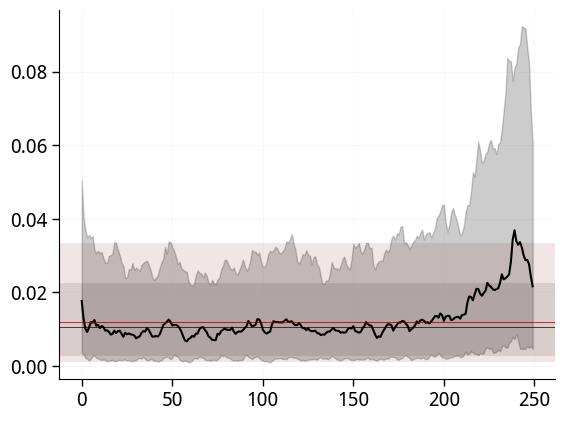

In [ ]:
# plt.plot(np.arange(0, 1000, 1), np.quantile(morlet_ensemble_pic, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0))
# plt.fill_between(np.arange(0, 1000, 1), np.quantile(morlet_ensemble_pic, 0.1, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), np.quantile(morlet_ensemble_pic, 0.9, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), alpha=0.1)

plt.axhline(np.quantile(np.quantile(morlet_ensemble_pic, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.5), color='k', lw=0.5)
plt.axhspan(np.quantile(np.quantile(morlet_ensemble_pic, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.1), np.quantile(np.quantile(morlet_ensemble_pic, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.9), color='k', lw=0.0, alpha=0.1)

plt.plot(np.arange(0, 250, 1), np.quantile(morlet_ensemble_trans, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), color='k')
plt.fill_between(np.arange(0, 250, 1), np.quantile(morlet_ensemble_trans, 0.1, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), np.quantile(morlet_ensemble_trans, 0.9, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), alpha=0.2, color='k')

# plt.plot(np.arange(0, 250, 1), np.quantile(morlet_ensemble_trans, 0.5, axis=0)[(common_scales > 3) & (common_scales <= 8)].mean(axis=0))
# plt.fill_between(np.arange(0, 250, 1), np.quantile(morlet_ensemble_trans, 0.1, axis=0)[(common_scales > 3) & (common_scales <= 8)].mean(axis=0), np.quantile(morlet_ensemble_trans, 0.9, axis=0)[(common_scales > 3) & (common_scales <= 8)].mean(axis=0), alpha=0.1)

# plt.plot(np.arange(0, 1000, 1), np.quantile(morlet_ensemble_stable, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0))
# plt.fill_between(np.arange(0, 1000, 1), np.quantile(morlet_ensemble_stable, 0.1, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), np.quantile(morlet_ensemble_stable, 0.9, axis=0)[(common_scales >= 2) & (common_scales <= 7)].mean(axis=0), alpha=0.1)

plt.axhline(np.quantile(np.quantile(morlet_ensemble_stable, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.5), color='maroon', lw=0.5)
plt.axhspan(np.quantile(np.quantile(morlet_ensemble_stable, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.1), np.quantile(np.quantile(morlet_ensemble_stable, 0.5, axis=0)[(common_scales >= 2) & (common_scales <= 7)], 0.9), color='maroon', lw=0.0, alpha=0.1)
plot_decorator()